In [11]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy, MulticlassConfusionMatrix

from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.binary_subset import BinaryPairDataset

from models.basemodel import CNNWithSizeMLP
from models.basemodel_256 import CNN256WithSizeMLP
from models.basemodel_256_multilayer import CNN256WithSizeMLP_multi
from models.convnext_model import ConvNeXtTinyWithSize
from models.specialist_binary import BinarySpecialist
from models.convnext_384 import ConvNeXtTiny384WithSize
from models.convnext_lin import ConvNeXtTinyLinearWithSize

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix, plot_confusion_matrices_horizontal
from engine.data_setup import setup_datasets
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.augmented_dataset import AugmentedPollenDataset

from engine.specialist_pair import choose_specialist_pair
from engine.train_specialist import train_binary_specialist
from engine.two_stage_infer import two_stage_predict

from loss_fn.focal_loss import FocalLoss

from engine.random_seed import seed_everything
from Data_Utility.config import TRAIN_DIR, TEST_DIR, EXCEL_PATH

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
SEED = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



Using device: cuda


In [13]:
test_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/TestData_sensi'
train_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/TrainData_sensi'
test_excel_path = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Size_features/size_data.xlsx'


def collect_filenames(root_dir):
    """
    Collect all image filenames recursively from root_dir.
    Returns list of filenames (without path).
    """
    filenames = []
    for species in os.listdir(root_dir):
        species_dir = os.path.join(root_dir, species)
        if not os.path.isdir(species_dir):
            continue

        for fn in os.listdir(species_dir):
            if fn.lower().endswith(('.png', '.jpg', '.jpeg')):
                filenames.append(fn)
    return filenames


# Collect filenames
train_files = collect_filenames(train_dir)
test_files  = collect_filenames(test_dir)

print(f"Train images: {len(train_files)}")
print(f"Test images: {len(test_files)}")

Train images: 8078
Test images: 1922


In [14]:
# Convert to pandas DataFrame
train_df = pd.DataFrame({'filename': train_files})
test_df  = pd.DataFrame({'filename': test_files})

# Extract flower ID (before underscore)
train_df['flower_id'] = train_df['filename'].str.split(' ').str[-1].str.split('_').str[0]
test_df['flower_id']  = test_df['filename'].str.split(' ').str[-1].str.split('_').str[0]


print(train_df.head())

                             filename flower_id
0  Tussilago farfara 1000328_3192.png   1000328
1  Tussilago farfara 1005387_1866.png   1005387
2  Tussilago farfara 1001625_1653.png   1001625
3  Tussilago farfara 1000328_1189.png   1000328
4   Tussilago farfara 1004811_656.png   1004811


In [15]:
train_flower_ids = set(train_df['flower_id'])
test_flower_ids  = set(test_df['flower_id'])

overlap = train_flower_ids.intersection(test_flower_ids)

print(f"Unique flower IDs in train: {len(train_flower_ids)}")
print(f"Unique flower IDs in test: {len(test_flower_ids)}")
print(f"Overlap in flower IDs: {len(overlap)}")

print(f"\n Overlapping flower IDs: {overlap}")


Unique flower IDs in train: 49
Unique flower IDs in test: 11
Overlap in flower IDs: 0

 Overlapping flower IDs: set()


In [16]:
def extract_species_from_filename(fn):
    # remove trailing "1234567_89.png"
    return " ".join(fn.split(" ")[:-1])

train_df["species"] = train_df["filename"].apply(extract_species_from_filename)
test_df["species"] = test_df["filename"].apply(extract_species_from_filename)

print(train_df.head())
print(test_df.head())

                             filename flower_id            species
0  Tussilago farfara 1000328_3192.png   1000328  Tussilago farfara
1  Tussilago farfara 1005387_1866.png   1005387  Tussilago farfara
2  Tussilago farfara 1001625_1653.png   1001625  Tussilago farfara
3  Tussilago farfara 1000328_1189.png   1000328  Tussilago farfara
4   Tussilago farfara 1004811_656.png   1004811  Tussilago farfara
                             filename flower_id            species
0    Tussilago farfara 1005388_97.png   1005388  Tussilago farfara
1  Tussilago farfara 1005388_1993.png   1005388  Tussilago farfara
2  Tussilago farfara 1005388_1175.png   1005388  Tussilago farfara
3  Tussilago farfara 1005388_2027.png   1005388  Tussilago farfara
4   Tussilago farfara 1005388_975.png   1005388  Tussilago farfara


In [17]:
flowers_per_species = (
    train_df.groupby("species")["flower_id"]
    .nunique()
    .sort_values(ascending=False)
)
print("\nNumber of unique flowers per species in training set:")
print(flowers_per_species)


Number of unique flowers per species in training set:
species
Brassica napus             8
Cichorium intybus          8
Bellis perennis            6
Capsella bursa-pastoris    5
Tussilago farfara          5
Crepis capillaris          4
Hieracium umbellatum       4
Hypochaeris radicata       4
Tragopogon pratensis       3
Sonchus arvensis           2
Name: flower_id, dtype: int64


In [18]:
flowers_per_species = (
    test_df.groupby("species")["flower_id"]
    .nunique()
    .sort_values(ascending=False)
)
print("\nNumber of unique flowers per species in test set:")
print(flowers_per_species)


Number of unique flowers per species in test set:
species
Brassica napus             2
Bellis perennis            1
Capsella bursa-pastoris    1
Cichorium intybus          1
Crepis capillaris          1
Hieracium umbellatum       1
Hypochaeris radicata       1
Sonchus arvensis           1
Tragopogon pratensis       1
Tussilago farfara          1
Name: flower_id, dtype: int64


In [19]:
size_df = pd.read_excel(test_excel_path)

size_df["flower_id"] = (
    size_df["ping_name"]
    .astype(str)
    .str.split(" ").str[-1]
    .str.split("_").str[0]
)

size_df["species"] = size_df["anyname"]

print(size_df[["ping_name", "species", "flower_id", "majoraxis", "minoraxis"]].head())

                          ping_name          species flower_id  majoraxis  \
0  Bellis perennis 1001572_1013.png  Bellis perennis   1001572    26.1271   
1  Bellis perennis 1001572_1019.png  Bellis perennis   1001572    23.2606   
2  Bellis perennis 1001572_1022.png  Bellis perennis   1001572    25.6662   
3  Bellis perennis 1001572_1039.png  Bellis perennis   1001572    25.2603   
4  Bellis perennis 1001572_1057.png  Bellis perennis   1001572    28.9809   

   minoraxis  
0    24.5456  
1    22.8500  
2    24.1594  
3    24.8495  
4    25.3248  


In [20]:
train_size_df = size_df[size_df["ping_name"].isin(train_files)].copy()

print("Rows in Excel matching train images:", len(train_size_df))

Rows in Excel matching train images: 7922


In [21]:
test_size_df = size_df[size_df["ping_name"].isin(test_files)].copy()

print("Rows in Excel matching test images:", len(test_size_df))

Rows in Excel matching test images: 1922


In [23]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=False
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
bootstrap_impute_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 7922
Dataset setup complete.


In [24]:
classes

['Bellis perennis',
 'Brassica napus',
 'Capsella bursa-pastoris',
 'Cichorium intybus',
 'Crepis capillaris',
 'Hieracium umbellatum',
 'Hypochaeris radicata',
 'Sonchus arvensis',
 'Tragopogon pratensis',
 'Tussilago farfara']

In [56]:
species_name = "Hypochaeris radicata"

train_species_df = train_df[train_df["species"] == species_name].copy()
print("Train images for species:", len(train_species_df))
print(train_species_df.head())

Train images for species: 800
                                   filename flower_id               species
6461  Hypochaeris radicata 1001325_1555.png   1001325  Hypochaeris radicata
6462  Hypochaeris radicata 1005327_1111.png   1005327  Hypochaeris radicata
6463  Hypochaeris radicata 1012069_1430.png   1012069  Hypochaeris radicata
6464  Hypochaeris radicata 1012069_1445.png   1012069  Hypochaeris radicata
6465  Hypochaeris radicata 1010554_1236.png   1010554  Hypochaeris radicata


In [51]:
species_name = "Crepis capillaris"

train_species_df = train_df[train_df["species"] == species_name].copy()
print("Train images for species:", len(train_species_df))
print(train_species_df.head())

Train images for species: 800
                                filename flower_id            species
3157    Crepis capillaris 1010538_81.png   1010538  Crepis capillaris
3158  Crepis capillaris 1009512_4057.png   1009512  Crepis capillaris
3159   Crepis capillaris 1009502_109.png   1009502  Crepis capillaris
3160  Crepis capillaris 1009502_1546.png   1009502  Crepis capillaris
3161  Crepis capillaris 1000322_3204.png   1000322  Crepis capillaris


In [57]:
excel_species_df = size_df[size_df["ping_name"].isin(train_species_df["filename"])].copy()

print("Excel rows matching train images for species:", len(excel_species_df))
print(excel_species_df.head())

Excel rows matching train images for species: 717
      acceptid               anyname      family  \
5927    220205  Hypochaeris radicata  Asteraceae   
5928    220205  Hypochaeris radicata  Asteraceae   
5929    220205  Hypochaeris radicata  Asteraceae   
5930    220205  Hypochaeris radicata  Asteraceae   
5931    220205  Hypochaeris radicata  Asteraceae   

                                  ping_name  majoraxis  minoraxis flower_id  \
5927    Hypochaeris radicata 1001325_10.png    29.6641    28.0316   1001325   
5928  Hypochaeris radicata 1001325_1023.png    31.0718    28.3015   1001325   
5929  Hypochaeris radicata 1001325_1135.png    32.1123    31.4555   1001325   
5930  Hypochaeris radicata 1001325_1237.png    30.1631    29.2202   1001325   
5931  Hypochaeris radicata 1001325_1243.png    27.4169    25.5740   1001325   

                   species  
5927  Hypochaeris radicata  
5928  Hypochaeris radicata  
5929  Hypochaeris radicata  
5930  Hypochaeris radicata  
5931  Hypochaeris

In [58]:
excel_species_df["flower_id"] = (
    excel_species_df["ping_name"].str.split(" ").str[-1].str.split("_").str[0]
)

In [59]:
train_counts = (
    train_species_df.groupby("flower_id")
    .size()
    .reset_index(name="n_train_images")
)

excel_counts = (
    excel_species_df.groupby("flower_id")
    .size()
    .reset_index(name="n_excel_matches")
)

compare_df = train_counts.merge(excel_counts, on="flower_id", how="left")
compare_df["n_excel_matches"] = compare_df["n_excel_matches"].fillna(0).astype(int)
compare_df["all_images_exist_in_excel"] = (
    compare_df["n_train_images"] == compare_df["n_excel_matches"]
)

print(compare_df.sort_values("flower_id"))

  flower_id  n_train_images  n_excel_matches  all_images_exist_in_excel
0   1001325             200              117                      False
1   1005327             200              200                       True
2   1010554             200              200                       True
3   1012069             200              200                       True


In [55]:
complete_flower_ids = compare_df.loc[
    compare_df["all_images_exist_in_excel"], "flower_id"
].tolist()

print("Flower IDs with all train images present in Excel:", species_name)
print(complete_flower_ids)

Flower IDs with all train images present in Excel: Crepis capillaris
['1009502', '1009512', '1010538']


In [60]:
complete_flower_ids = compare_df.loc[
    compare_df["all_images_exist_in_excel"], "flower_id"
].tolist()

print("Flower IDs with all train images present in Excel:", species_name)
print(complete_flower_ids)

Flower IDs with all train images present in Excel: Hypochaeris radicata
['1005327', '1010554', '1012069']


In [17]:
import os
import torch
import torchvision.transforms as T
from torch.utils.data import random_split
from Data_Utility.split_groups import group_train_val_split

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.augmented_dataset import AugmentedPollenDataset
from Data_Utility.config_sensi import TRAIN_DIR, TEST_DIR, EXCEL_PATH
from Data_Utility.bootstrap_impute import build_bootstrap_pools

def list_image_filenames(root_dir):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    names = []
    for class_name in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fn in os.listdir(class_dir):
            if fn.lower().endswith(exts):
                names.append(fn) 
    return set(names)


def setup_datasets(
    fill_missing_bool=False,
    val_bool=False,
    aug_bool=False,
    norm_bool=False,
    sep_val_bool=False,
    quota_bool=False,
    bootstrap_impute_bool=False,
    seed=42
    ,return_flowerid: bool = False
):
    """
    Builds datasets using fixed project paths.
    Optional:
        - validation split
        - augmentation
        - Normalization of size
    """
    train_filenames = list_image_filenames(TRAIN_DIR)

    size_lookup, species_mean_lookup, train_mean, train_std = lookup_size_from_excel(
    EXCEL_PATH,
    stats_filenames=train_filenames
    ,quota_bool=quota_bool
    )
    #size_lookup, species_mean_lookup, global_mean, global_std = lookup_size_from_excel(EXCEL_PATH)
    
    if bootstrap_impute_bool:
        species_pool, flower_pool = build_bootstrap_pools(EXCEL_PATH, list(train_filenames), quota_bool=quota_bool)
    else:
        species_pool, flower_pool = None, None
        
    classes = sorted([
        d for d in os.listdir(TRAIN_DIR)
        if os.path.isdir(os.path.join(TRAIN_DIR, d))
    ])

    class_to_idx = {c: i for i, c in enumerate(classes)}
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    base_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    aug_transform = T.Compose([
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.2),
        T.RandomRotation(degrees=20),
        T.RandomApply([
            T.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02
            )
        ], p=0.4),
        T.RandomApply([
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
        ], p=0.15),
    ])

    val_dataset = None

    if aug_bool:

        train_dataset = AugmentedPollenDataset(
            img_dir=TRAIN_DIR,
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            fill_missing_bool=fill_missing_bool,
            transform_base=base_transform,
            transform_aug=aug_transform,
            augment=True,
            normalize_size=norm_bool,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            global_mean=train_mean,
            global_std=train_std,
            seed=seed,
            shuffle_final=True,
            print_summary=True
            ,return_flowerid=return_flowerid
        )

        test_dataset = AugmentedPollenDataset(
            img_dir=TEST_DIR,
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            fill_missing_bool=False,
            transform_base=base_transform,
            transform_aug=None,
            augment=False,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            normalize_size=norm_bool,
            global_mean=train_mean,
            global_std=train_std,
            seed=seed,
            shuffle_final=True,
            print_summary=True,
            return_flowerid=return_flowerid
        )

    else:
        train_dataset = PollenFolderWithSizeDataset(
            img_dir=TRAIN_DIR,
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            transform=base_transform
            ,fill_missing_bool=fill_missing_bool
            ,normalize_size=norm_bool,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            global_mean=train_mean,
            global_std=train_std
            ,return_flowerid=return_flowerid
        )
        
        test_dataset = PollenFolderWithSizeDataset(
            img_dir=TEST_DIR,
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            transform=base_transform
            ,fill_missing_bool=False
            ,normalize_size=norm_bool,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            global_mean=train_mean,
            global_std=train_std
            ,return_flowerid=return_flowerid
        )


    if val_bool:
        train_size = int(0.8 * len(train_dataset))
        val_size = len(train_dataset) - train_size

        generator = torch.Generator().manual_seed(seed)

        train_dataset, val_dataset = random_split(
            train_dataset,
            [train_size, val_size],
            generator=generator
        )

        print(f"Train subset size: {len(train_dataset)}")
        print(f"Validation subset size: {len(val_dataset)}")
        
    elif sep_val_bool:
        train_dataset, val_dataset = group_train_val_split(
            train_dataset,
            val_ratio=0.2,
            seed=seed
        )
        
        

    print(f"Train subset size: {len(train_dataset)}")
    if val_dataset is not None:
        print(f"Validation subset size: {len(val_dataset)}")

    print("Dataset setup complete.")

    return train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class, classes

In [31]:


train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=True,
    aug_bool=True
    ,return_flowerid=True
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/TrainData_sensi' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/TrainData_sensi ===========
fill_missing_bool: False
bootstrap_impute_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/TrainData_sensi' ===
Original samples kept: 7922
Extra augmented samples added: 778
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 856 (add 14)
  Brassica napus: 795 

In [19]:
img, size, y = train_dataset[0]
print(size) 
len(train_dataset)

tensor([30.7455, 27.7806])


6960

In [23]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [24]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="convnext_fill_val_aug_sensi_C1005299_H1005278.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:54<00:00,  4.00it/s]


Epoch 1/40 | Train Loss: 0.3883, Train Acc: 0.8662
| Val Acc: 0.9466
Val Recall per class: tensor([1.0000, 1.0000, 0.9253, 1.0000, 0.9697, 0.6879, 0.9096, 0.9600, 0.9841,
        1.0000])
Saved new best model (Val Acc = 0.9466)


100%|██████████| 218/218 [00:54<00:00,  4.00it/s]


Epoch 2/40 | Train Loss: 0.0984, Train Acc: 0.9701
| Val Acc: 0.9862
Saved new best model (Val Acc = 0.9862)


100%|██████████| 218/218 [01:04<00:00,  3.39it/s]


...

Epoch 20/40 | Train Loss: 0.0035, Train Acc: 0.9994
| Val Acc: 0.9937
Val Recall per class: tensor([0.9941, 0.9949, 0.9770, 0.9940, 1.0000, 0.9809, 1.0000, 1.0000, 0.9947,
        1.0000])


100%|██████████| 218/218 [01:21<00:00,  2.66it/s]


Epoch 21/40 | Train Loss: 0.0412, Train Acc: 0.9889
| Val Acc: 0.9776


100%|██████████| 218/218 [01:23<00:00,  2.60it/s]


Epoch 22/40 | Train Loss: 0.0253, Train Acc: 0.9912
| Val Acc: 0.9897
Early stopping at epoch 22. Best Val Acc = 0.9948 at epoch 14.
Reloaded best model from epoch 14 (Val Acc=0.9948)



=== Backbone Feature Inspection ===
Min of mins: -11.172706604003906
Max of maxs: 14.399003982543945
Mean of batch means: 0.03017232964792457
Mean of batch stds: 1.1537775231189416

Test Accuracy: 0.6920
Test Recall per class:
Class 0 (Bellis perennis): 0.5915
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0800
Class 5 (Hieracium umbellatum): 0.8800
Class 6 (Hypochaeris radicata): 0.7150
Class 7 (Sonchus arvensis): 0.2066
Class 8 (Tragopogon pratensis): 0.9819
Class 9 (Tussilago farfara): 1.0000


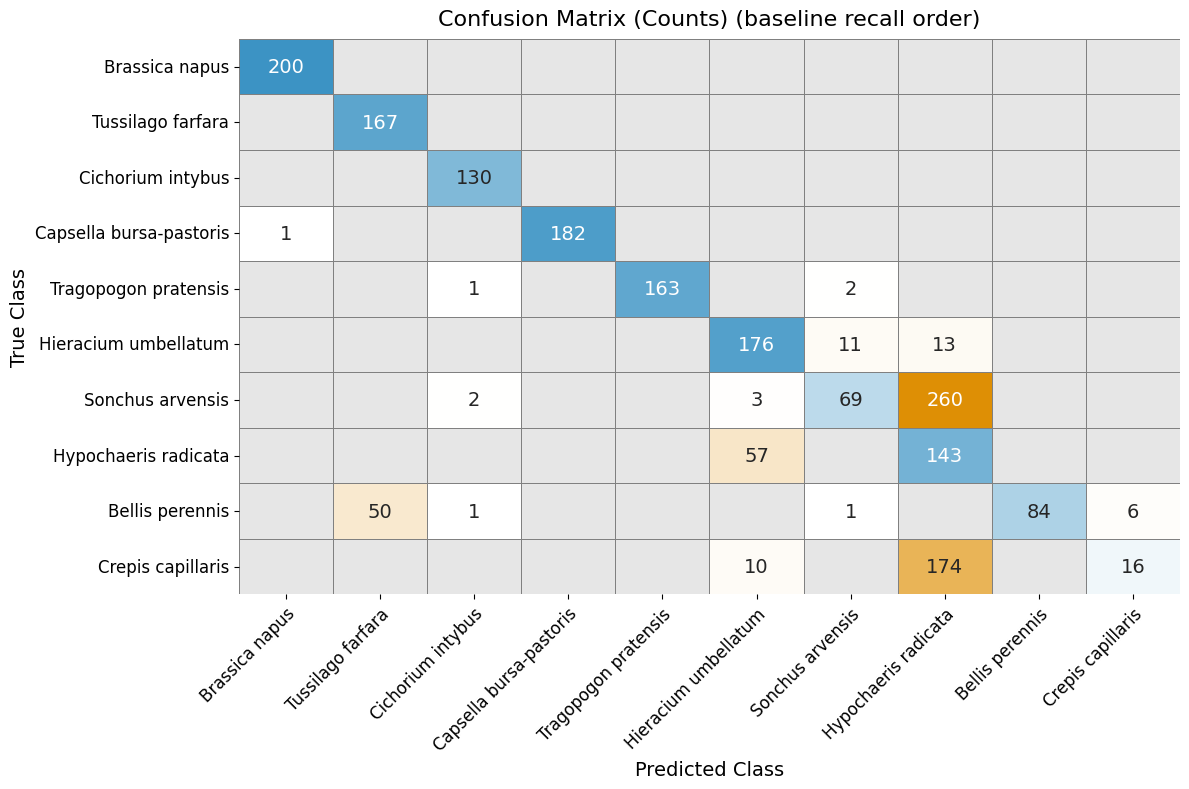

In [25]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnext_fill_val_aug_sensi_C1005299_H1005278.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class_M1, accuracy_M1, probs_M1, ys_M1, conf_M1 = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_M1:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_M1):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M1, idx_to_class, normalize=False)

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_pca_tsne_flowerid_two_panels(
    X_train,
    y_train,
    flower_id_train,
    X_test,
    y_test,
    flower_id_test,
    class_names,
    confusing_classes,
    method="pca",
    figsize=(6.8, 3.4),   # LaTeX-friendly full-width figure
    point_size=14,
    alpha=0.80,
    title_fontsize=11,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=8,
    random_state=42,
    show_flower_legend=False,
    max_flower_ids_in_legend=12,
    same_axes=True,
    save_path=None,
    dpi=300
):
    """
    Two-panel PCA/t-SNE plot:
      - left panel: Train
      - right panel: Test
      - species encoded by marker shape
      - flower_id encoded by color

    Parameters
    ----------
    flower_id_train, flower_id_test : array-like of shape (n_samples,)
        Flower IDs aligned with X_train/y_train and X_test/y_test.
    show_flower_legend : bool
        Whether to show a flower-ID legend.
    max_flower_ids_in_legend : int
        Only show flower legend if number of unique flower IDs is small enough.
    """

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)
    flower_id_train = np.asarray(flower_id_train)

    X_test = np.asarray(X_test)
    y_test = np.asarray(y_test)
    flower_id_test = np.asarray(flower_id_test)

    confusing_idx = [class_names.index(c) for c in confusing_classes]

    train_mask = np.isin(y_train, confusing_idx)
    test_mask = np.isin(y_test, confusing_idx)

    X_train_sub = X_train[train_mask]
    y_train_sub = y_train[train_mask]
    flower_train_sub = flower_id_train[train_mask]

    X_test_sub = X_test[test_mask]
    y_test_sub = y_test[test_mask]
    flower_test_sub = flower_id_test[test_mask]

    if len(X_train_sub) == 0 or len(X_test_sub) == 0:
        raise ValueError("Filtered train or test set is empty.")

    # Same embedding space
    if method.lower() == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
        X_train_2d = reducer.fit_transform(X_train_sub)
        X_test_2d = reducer.transform(X_test_sub)
        xlabel, ylabel = "PC1", "PC2"

    elif method.lower() == "tsne":
        X_all = np.vstack([X_train_sub, X_test_sub])
        reducer = TSNE(
            n_components=2,
            perplexity=30,
            init="pca",
            learning_rate="auto",
            random_state=random_state
        )
        X_all_2d = reducer.fit_transform(X_all)
        X_train_2d = X_all_2d[:len(X_train_sub)]
        X_test_2d = X_all_2d[len(X_train_sub):]
        xlabel, ylabel = "t-SNE 1", "t-SNE 2"

    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=False, sharey=False)

    # Same species = same marker shape
    available_markers = ["o", "^", "s", "D", "P", "X", "v", "<", ">", "*"]
    if len(confusing_idx) > len(available_markers):
        raise ValueError("Too many confusing classes for available marker styles.")

    marker_map = {
        cls_idx: available_markers[i]
        for i, cls_idx in enumerate(confusing_idx)
    }

    # Same flower_id = same color across train and test
    all_flower_ids = np.unique(np.concatenate([flower_train_sub, flower_test_sub]))
    cmap = plt.get_cmap("tab20", len(all_flower_ids))
    flower_color_map = {fid: cmap(i) for i, fid in enumerate(all_flower_ids)}

    # --- Train panel ---
    for cls_idx in confusing_idx:
        cls_mask = (y_train_sub == cls_idx)
        for fid in np.unique(flower_train_sub[cls_mask]):
            mask = cls_mask & (flower_train_sub == fid)
            axes[0].scatter(
                X_train_2d[mask, 0],
                X_train_2d[mask, 1],
                s=point_size,
                alpha=alpha,
                marker=marker_map[cls_idx],
                color=flower_color_map[fid],
                edgecolors="black",
                linewidths=0.35
            )

    # --- Test panel ---
    for cls_idx in confusing_idx:
        cls_mask = (y_test_sub == cls_idx)
        for fid in np.unique(flower_test_sub[cls_mask]):
            mask = cls_mask & (flower_test_sub == fid)
            axes[1].scatter(
                X_test_2d[mask, 0],
                X_test_2d[mask, 1],
                s=point_size,
                alpha=alpha,
                marker=marker_map[cls_idx],
                color=flower_color_map[fid],
                edgecolors="black",
                linewidths=0.35
            )

    # Same scale across panels
    if same_axes:
        x_min = min(X_train_2d[:, 0].min(), X_test_2d[:, 0].min())
        x_max = max(X_train_2d[:, 0].max(), X_test_2d[:, 0].max())
        y_min = min(X_train_2d[:, 1].min(), X_test_2d[:, 1].min())
        y_max = max(X_train_2d[:, 1].max(), X_test_2d[:, 1].max())

        axes[0].set_xlim(x_min, x_max)
        axes[1].set_xlim(x_min, x_max)
        axes[0].set_ylim(y_min, y_max)
        axes[1].set_ylim(y_min, y_max)

    axes[0].set_title("Train", fontsize=title_fontsize - 2)
    axes[1].set_title("Test", fontsize=title_fontsize - 2)

    for ax in axes:
        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)
        ax.tick_params(labelsize=tick_fontsize)
    # Species legend: shape only, shown inside left panel at upper-left corner
    # Species legend: shape only
    species_handles = [
        Line2D(
            [0], [0],
            marker=marker_map[cls_idx],
            linestyle="None",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=8,
            label=class_names[cls_idx]
        )
        for cls_idx in confusing_idx
    ]

    fig.legend(
        handles=species_handles,
        #title="Species",
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
        loc="upper left",
        #bbox_to_anchor=(0.86, 0.98)
    )

    # Optional flower legend
    if show_flower_legend and len(all_flower_ids) <= max_flower_ids_in_legend:
        flower_handles = [
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markerfacecolor=flower_color_map[fid],
                markeredgecolor="black",
                markersize=7,
                label=str(fid)
            )
            for fid in all_flower_ids
        ]

        fig.legend(
            handles=flower_handles,
            title="Flower ID (color)",
            fontsize=max(8, legend_fontsize - 1),
            title_fontsize=max(8, legend_fontsize - 1),
            loc="upper right",
            #bbox_to_anchor=(0.86, 0.10)
            #frameon=True
        )

    fig.suptitle(f"{method.upper()}", fontsize=title_fontsize)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    if save_path is not None:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    return {
        "flower_color_map": flower_color_map,
        "marker_map": marker_map
    }

In [33]:
import numpy as np
import torch

def extract_fused_features(model, loader, device):
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for x_img, x_size, y in loader:
            x_img = x_img.to(device)
            x_size = x_size.to(device).float()
            y = y.to(device)

            features = model.forward_features(x_img, x_size)

            all_features.append(features.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y

In [34]:
import numpy as np
import torch

def extract_features_labels_flowerids(model, loader, device):
    model.eval()

    all_features = []
    all_labels = []
    all_filenames = []
    all_flower_ids = []

    with torch.no_grad():
        for x_img, x_size, y, filenames, flower_ids in loader:
            x_img = x_img.to(device)
            x_size = x_size.to(device).float()
            y = y.to(device)

            feats = model.forward_features(x_img, x_size)

            all_features.append(feats.cpu().numpy())
            all_labels.append(y.cpu().numpy())
            all_filenames.extend(list(filenames))
            all_flower_ids.extend(list(flower_ids))

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y, np.array(all_filenames), np.array(all_flower_ids)

In [35]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

X_train, y_train,filenames_train, flower_ids_train = extract_features_labels_flowerids(model, train_loader, device)
X_test, y_test,filenames_test, flower_ids_test = extract_features_labels_flowerids(model, test_loader, device)

#X_train, y_train = extract_fused_features(model, train_loader, device)
#X_test, y_test = extract_fused_features(model, test_loader, device)

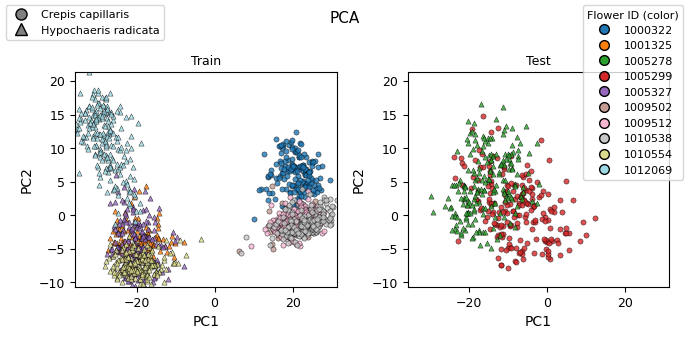

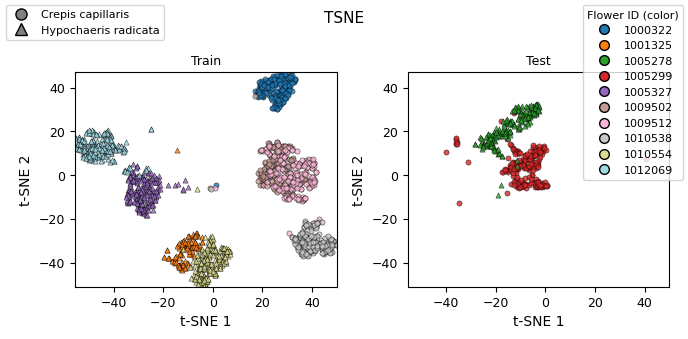

{'flower_color_map': {'1000322': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1001325': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
  '1005278': (0.17254901960784313,
   0.6274509803921569,
   0.17254901960784313,
   1.0),
  '1005299': (0.8392156862745098,
   0.15294117647058825,
   0.1568627450980392,
   1.0),
  '1005327': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
  '1009502': (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
  '1009512': (0.9686274509803922, 0.7137254901960784, 0.8235294117647058, 1.0),
  '1010538': (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
  '1010554': (0.8588235294117647, 0.8588235294117647, 0.5529411764705883, 1.0),
  '1012069': (0.6196078431372549,
   0.8549019607843137,
   0.8980392156862745,
   1.0)},
 'marker_map': {4: 'o', 6: '^'}}

In [36]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata"
]

plot_pca_tsne_flowerid_two_panels(
    X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/pca_crepis_hypo.png"
   
)

plot_pca_tsne_flowerid_two_panels(
   X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/tsne_crepis_hypo.png"
    
)

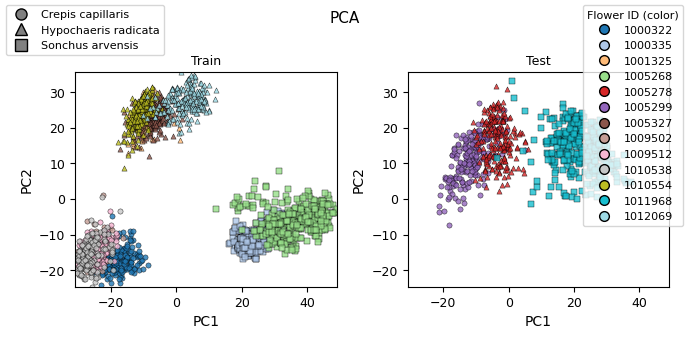

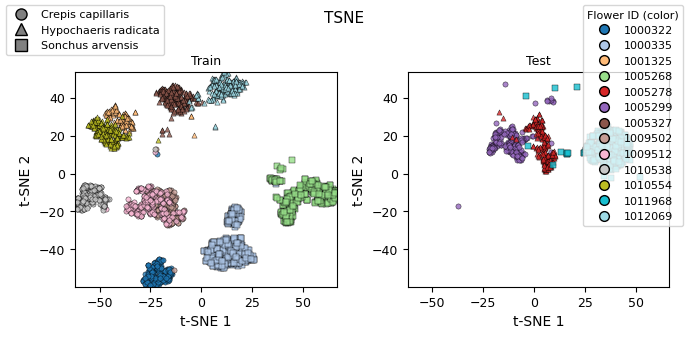

{'flower_color_map': {'1000322': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1000335': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
  '1001325': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
  '1005268': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
  '1005278': (0.8392156862745098,
   0.15294117647058825,
   0.1568627450980392,
   1.0),
  '1005299': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
  '1005327': (0.5490196078431373,
   0.33725490196078434,
   0.29411764705882354,
   1.0),
  '1009502': (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
  '1009512': (0.9686274509803922, 0.7137254901960784, 0.8235294117647058, 1.0),
  '1010538': (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
  '1010554': (0.7372549019607844,
   0.7411764705882353,
   0.13333333333333333,
   1.0),
  '1011968': (0.09019607843137255,
   0.7450980392156863,
   0.8117647058823

In [37]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata",
    "Sonchus arvensis"
]


plot_pca_tsne_flowerid_two_panels(
    X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/pca_crepis_hypo.png"
    ,max_flower_ids_in_legend=50
   
)

plot_pca_tsne_flowerid_two_panels(
   X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/tsne_crepis_hypo.png"
    ,max_flower_ids_in_legend=50
    
)

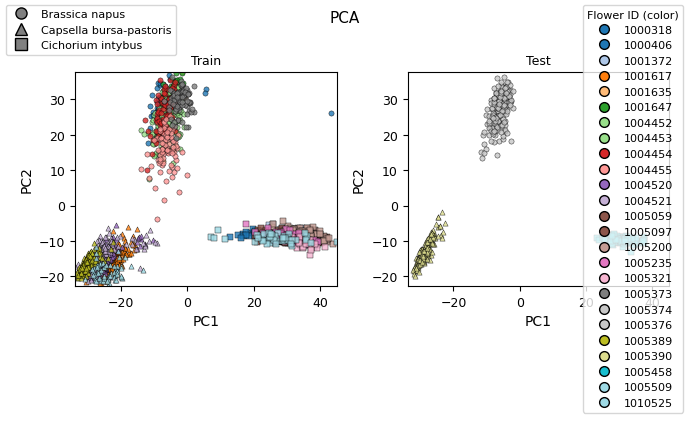

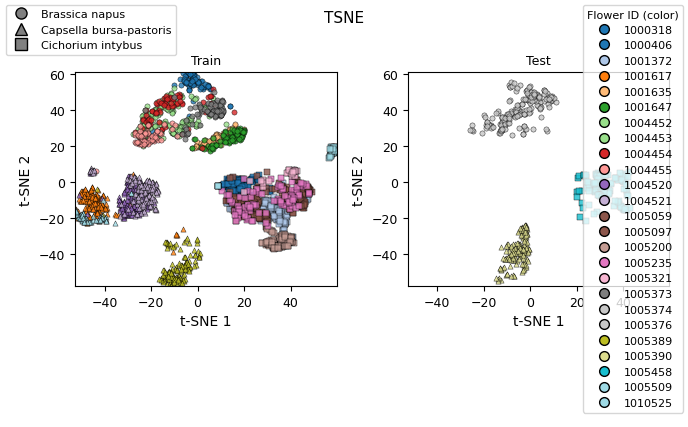

{'flower_color_map': {'1000318': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1000406': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1001372': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
  '1001617': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
  '1001635': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
  '1001647': (0.17254901960784313,
   0.6274509803921569,
   0.17254901960784313,
   1.0),
  '1004452': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
  '1004453': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
  '1004454': (0.8392156862745098,
   0.15294117647058825,
   0.1568627450980392,
   1.0),
  '1004455': (1.0, 0.596078431372549, 0.5882352941176471, 1.0),
  '1004520': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
  '1004521': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589, 1.0),
  '1005059': (0.549019607

In [38]:
well_classified_classes = [
    "Brassica napus",
    "Capsella bursa-pastoris",
    "Cichorium intybus"
]

plot_pca_tsne_flowerid_two_panels(
    X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=well_classified_classes,
    method="pca",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/pca_crepis_hypo.png"
    ,max_flower_ids_in_legend=50
   
)

plot_pca_tsne_flowerid_two_panels(
   X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=well_classified_classes,
    method="tsne",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/tsne_crepis_hypo.png"
    ,max_flower_ids_in_legend=50
    
)

# Testing all 16 cases

In [25]:
import os

def scan_master_samples(train_dir, test_dir):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    rows = []

    for split_name, root_dir in [("train", train_dir), ("test", test_dir)]:
        for class_name in sorted(os.listdir(root_dir)):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            for fn in sorted(os.listdir(class_dir)):
                if fn.lower().endswith(exts):
                    img_path = os.path.join(class_dir, fn)
                    flower_id = fn.split(" ")[-1].split("_")[0]
                    rows.append({
                        "img_path": img_path,
                        "class_name": class_name,
                        "filename": fn,
                        "flower_id": flower_id,
                        "original_split": split_name
                    })
    return rows

In [26]:
import itertools

CREPIS_FLOWERS = ["1009502", "1009512", "1010538", "1005299"]
HYPO_FLOWERS   = ["1005327", "1010554", "1012069", "1005278"]

ALL_CASES = list(itertools.product(CREPIS_FLOWERS, HYPO_FLOWERS))

In [27]:
def build_case_samples(master_rows, crepis_test_flower, hypo_test_flower):
    train_samples = []
    test_samples = []

    for row in master_rows:
        species = row["class_name"]
        flower_id = row["flower_id"]
        item = (row["img_path"], row["class_name"])

        if species == "Crepis capillaris":
            if flower_id == crepis_test_flower:
                test_samples.append(item)
            else:
                train_samples.append(item)

        elif species == "Hypochaeris radicata":
            if flower_id == hypo_test_flower:
                test_samples.append(item)
            else:
                train_samples.append(item)

        else:
            if row["original_split"] == "train":
                train_samples.append(item)
            else:
                test_samples.append(item)

    return train_samples, test_samples

In [28]:
def setup_sensitivity_datasets(
    crepis_test_flower,
    hypo_test_flower,
    train_dir,
    test_dir,
    excel_path,
    fill_missing_bool=False,
    val_bool=False,
    aug_bool=False,
    norm_bool=False,
    sep_val_bool=False,
    quota_bool=False,
    bootstrap_impute_bool=False,
    seed=42,
    return_flowerid=False
):
    import os
    import torch
    import torchvision.transforms as T
    from torch.utils.data import random_split

    master_rows = scan_master_samples(train_dir, test_dir)
    train_samples, test_samples = build_case_samples(
        master_rows,
        crepis_test_flower=crepis_test_flower,
        hypo_test_flower=hypo_test_flower
    )

    train_filenames = {os.path.basename(p) for p, _ in train_samples}

    size_lookup, species_mean_lookup, train_mean, train_std = lookup_size_from_excel(
        excel_path,
        stats_filenames=train_filenames,
        quota_bool=quota_bool
    )

    if bootstrap_impute_bool:
        species_pool, flower_pool = build_bootstrap_pools(
            excel_path,
            list(train_filenames),
            quota_bool=quota_bool
        )
    else:
        species_pool, flower_pool = None, None

    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])

    class_to_idx = {c: i for i, c in enumerate(classes)}
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    base_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    aug_transform = T.Compose([
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.2),
        T.RandomRotation(degrees=20),
        T.RandomApply([
            T.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02
            )
        ], p=0.4),
        T.RandomApply([
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
        ], p=0.15),
    ])

    val_dataset = None

    if aug_bool:
        train_dataset = AugmentedPollenDataset(
            img_dir=None,
            samples=train_samples,
            dataset_name=f"train_case_crepis_{crepis_test_flower}_hypo_{hypo_test_flower}",
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            fill_missing_bool=fill_missing_bool,
            transform_base=base_transform,
            transform_aug=aug_transform,
            augment=True,
            normalize_size=norm_bool,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            global_mean=train_mean,
            global_std=train_std,
            seed=seed,
            shuffle_final=True,
            print_summary=True,
            return_flowerid=return_flowerid
        )

        test_dataset = AugmentedPollenDataset(
            img_dir=None,
            samples=test_samples,
            dataset_name=f"test_case_crepis_{crepis_test_flower}_hypo_{hypo_test_flower}",
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            fill_missing_bool=False,
            transform_base=base_transform,
            transform_aug=None,
            augment=False,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            normalize_size=norm_bool,
            global_mean=train_mean,
            global_std=train_std,
            seed=seed,
            shuffle_final=False,
            print_summary=True,
            return_flowerid=return_flowerid
        )

    else:
        train_dataset = PollenFolderWithSizeDataset(
            img_dir=None,
            samples=train_samples,
            dataset_name=f"train_case_crepis_{crepis_test_flower}_hypo_{hypo_test_flower}",
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            transform=base_transform,
            fill_missing_bool=fill_missing_bool,
            normalize_size=norm_bool,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            global_mean=train_mean,
            global_std=train_std,
            return_flowerid=return_flowerid
        )

        test_dataset = PollenFolderWithSizeDataset(
            img_dir=None,
            samples=test_samples,
            dataset_name=f"test_case_crepis_{crepis_test_flower}_hypo_{hypo_test_flower}",
            class_to_idx=class_to_idx,
            size_lookup=size_lookup,
            species_mean_lookup=species_mean_lookup,
            transform=base_transform,
            fill_missing_bool=False,
            normalize_size=norm_bool,
            quota_bool=quota_bool,
            bootstrap_impute_bool=bootstrap_impute_bool,
            species_pool=species_pool,
            flower_pool=flower_pool,
            global_mean=train_mean,
            global_std=train_std,
            return_flowerid=return_flowerid
        )

    if val_bool:
        train_size = int(0.8 * len(train_dataset))
        val_size = len(train_dataset) - train_size
        generator = torch.Generator().manual_seed(seed)

        train_dataset, val_dataset = random_split(
            train_dataset,
            [train_size, val_size],
            generator=generator
        )

    elif sep_val_bool:
        train_dataset, val_dataset = group_train_val_split(
            train_dataset,
            val_ratio=0.2,
            seed=seed
        )

    print(f"Train subset size: {len(train_dataset)}")
    if val_dataset is not None:
        print(f"Validation subset size: {len(val_dataset)}")
    print(f"Test subset size: {len(test_dataset)}")
    print("Dataset setup complete.")

    return train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class, classes

In [29]:
val_dataset[0]

TypeError: 'NoneType' object is not subscriptable

In [1]:
import itertools

CREPIS_FLOWERS = ["1009502", "1009512", "1010538", "1005299"]
HYPO_FLOWERS   = ["1005327", "1010554", "1012069", "1005278"]

i =0

for crepis_flower in CREPIS_FLOWERS:
    for hypo_flower in HYPO_FLOWERS:
        i +=1
        print(f"Case {i}: Crepis flower = {crepis_flower} | Hypo flower = {hypo_flower}")

Case 1: Crepis flower = 1009502 | Hypo flower = 1005327
Case 2: Crepis flower = 1009502 | Hypo flower = 1010554
Case 3: Crepis flower = 1009502 | Hypo flower = 1012069
Case 4: Crepis flower = 1009502 | Hypo flower = 1005278
Case 5: Crepis flower = 1009512 | Hypo flower = 1005327
Case 6: Crepis flower = 1009512 | Hypo flower = 1010554
Case 7: Crepis flower = 1009512 | Hypo flower = 1012069
Case 8: Crepis flower = 1009512 | Hypo flower = 1005278
Case 9: Crepis flower = 1010538 | Hypo flower = 1005327
Case 10: Crepis flower = 1010538 | Hypo flower = 1010554
Case 11: Crepis flower = 1010538 | Hypo flower = 1012069
Case 12: Crepis flower = 1010538 | Hypo flower = 1005278
Case 13: Crepis flower = 1005299 | Hypo flower = 1005327
Case 14: Crepis flower = 1005299 | Hypo flower = 1010554
Case 15: Crepis flower = 1005299 | Hypo flower = 1012069
Case 16: Crepis flower = 1005299 | Hypo flower = 1005278


Running case: Crepis test flower = 1009502, Hypo test flower = 1005327
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009502_hypo_1005327' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:01<00:00,  3.57it/s]


Epoch 1/40 | Train Loss: 0.3467, Train Acc: 0.8853
| Val Acc: 0.9603
Val Recall per class: tensor([0.9941, 1.0000, 0.9568, 0.7617, 0.9939, 0.9873, 0.9937, 0.9461, 0.9948,
        1.0000])
Saved new best model (Val Acc = 0.9603)


100%|██████████| 218/218 [00:54<00:00,  4.00it/s]


Epoch 2/40 | Train Loss: 0.0909, Train Acc: 0.9726
| Val Acc: 0.9172


...

Epoch 10/40 | Train Loss: 0.0649, Train Acc: 0.9796
| Val Acc: 0.9776
Val Recall per class: tensor([1.0000, 0.9613, 0.9892, 0.9016, 0.9939, 0.9937, 1.0000, 0.9880, 1.0000,
        0.9591])


100%|██████████| 218/218 [01:22<00:00,  2.63it/s]


Epoch 11/40 | Train Loss: 0.0183, Train Acc: 0.9941
| Val Acc: 0.9828


100%|██████████| 218/218 [01:16<00:00,  2.83it/s]


Epoch 12/40 | Train Loss: 0.0430, Train Acc: 0.9861
| Val Acc: 0.9931
Early stopping at epoch 12. Best Val Acc = 0.9943 at epoch 4.
Reloaded best model from epoch 4 (Val Acc=0.9943)

=== Backbone Feature Inspection ===
Min of mins: -12.753504753112793
Max of maxs: 17.596277236938477
Mean of batch means: 0.01942346005540219
Mean of batch stds: 1.0283738736246453

Test Accuracy: 0.8803
Test Recall per class:
Class 0 (Bellis perennis): 0.9155
Class 1 (Brassica napus): 0.9900
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 1.0000
Class 5 (Hieracium umbellatum): 0.9850
Class 6 (Hypochaeris radicata): 0.0000
Class 7 (Sonchus arvensis): 0.9641
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


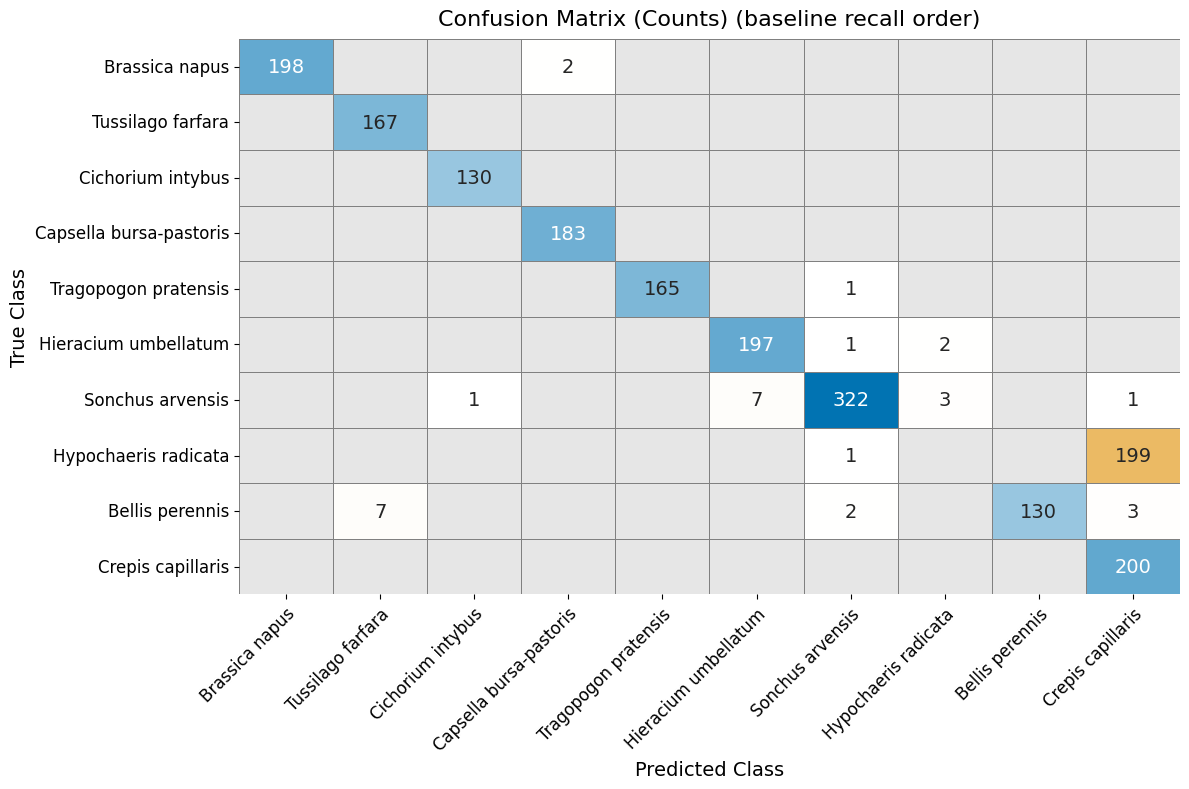

Running case: Crepis test flower = 1009502, Hypo test flower = 1010554
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009502_hypo_1010554' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:08<00:00,  3.17it/s]


Epoch 1/40 | Train Loss: 0.3922, Train Acc: 0.8682
| Val Acc: 0.9724
Val Recall per class: tensor([0.9941, 1.0000, 0.8865, 0.9275, 0.9939, 1.0000, 0.9688, 0.9701, 0.9948,
        1.0000])
Saved new best model (Val Acc = 0.9724)


100%|██████████| 218/218 [01:19<00:00,  2.73it/s]


Epoch 2/40 | Train Loss: 0.1046, Train Acc: 0.9680
| Val Acc: 0.9920
Saved new best model (Val Acc = 0.9920)


...

Epoch 20/40 | Train Loss: 0.0172, Train Acc: 0.9953
| Val Acc: 0.9954
Val Recall per class: tensor([1.0000, 1.0000, 0.9784, 1.0000, 0.9939, 1.0000, 1.0000, 0.9820, 1.0000,
        1.0000])


100%|██████████| 218/218 [01:16<00:00,  2.84it/s]


Epoch 21/40 | Train Loss: 0.0048, Train Acc: 0.9984
| Val Acc: 0.9966


100%|██████████| 218/218 [01:15<00:00,  2.90it/s]


Epoch 22/40 | Train Loss: 0.0056, Train Acc: 0.9983
| Val Acc: 0.9960
Early stopping at epoch 22. Best Val Acc = 0.9971 at epoch 14.
Reloaded best model from epoch 14 (Val Acc=0.9971)

=== Backbone Feature Inspection ===
Min of mins: -12.984244346618652
Max of maxs: 13.919320106506348
Mean of batch means: 0.02486869581635339
Mean of batch stds: 1.088716917350644

Test Accuracy: 0.8585
Test Recall per class:
Class 0 (Bellis perennis): 0.6549
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 1.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.0350
Class 7 (Sonchus arvensis): 0.9401
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


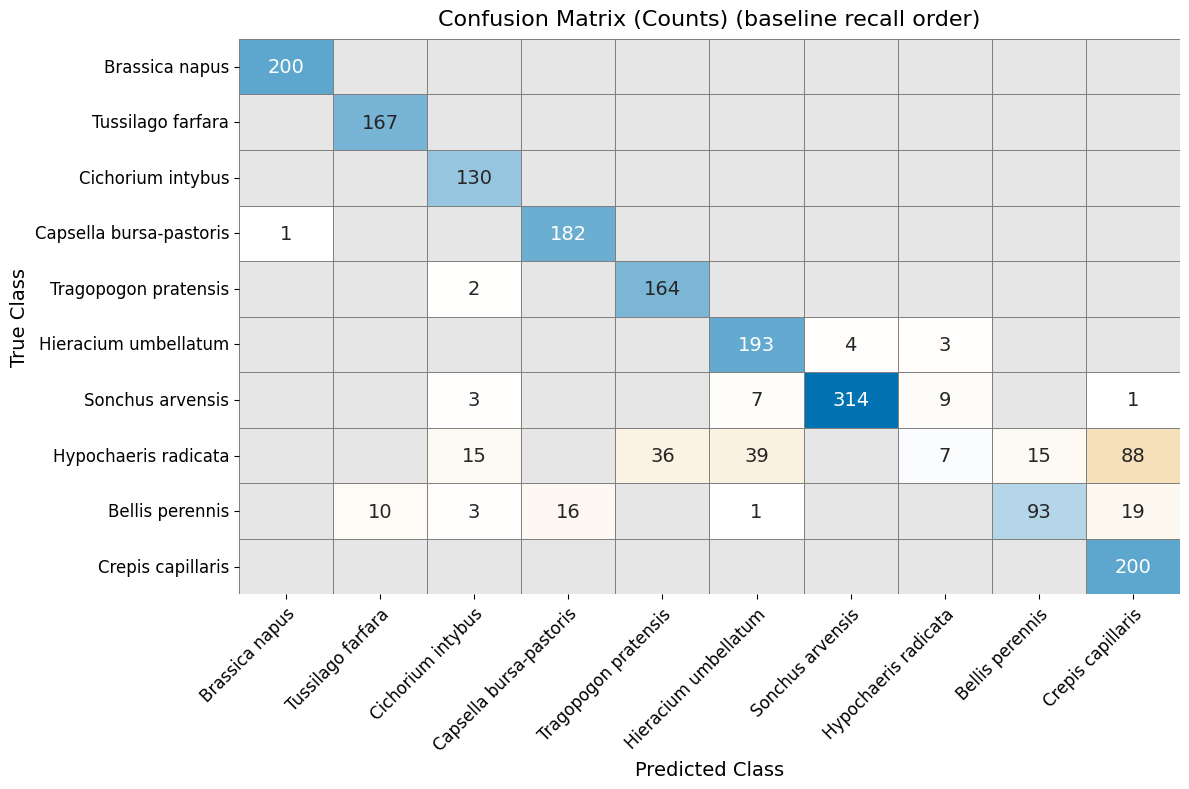

Running case: Crepis test flower = 1009502, Hypo test flower = 1012069
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009502_hypo_1012069' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:17<00:00,  2.80it/s]


Epoch 1/40 | Train Loss: 0.3972, Train Acc: 0.8668
| Val Acc: 0.9213
Val Recall per class: tensor([1.0000, 1.0000, 0.9189, 0.9948, 0.9766, 0.9937, 0.2727, 0.9832, 0.9944,
        1.0000])
Saved new best model (Val Acc = 0.9213)


100%|██████████| 218/218 [01:17<00:00,  2.83it/s]


Epoch 2/40 | Train Loss: 0.1075, Train Acc: 0.9671
| Val Acc: 0.9799
Saved new best model (Val Acc = 0.9799)


...

Epoch 12/40 | Train Loss: 0.0337, Train Acc: 0.9876
| Val Acc: 0.9822


100%|██████████| 218/218 [01:16<00:00,  2.84it/s]


Epoch 13/40 | Train Loss: 0.0160, Train Acc: 0.9958
| Val Acc: 0.9960


100%|██████████| 218/218 [01:15<00:00,  2.88it/s]


Epoch 14/40 | Train Loss: 0.0029, Train Acc: 0.9994
| Val Acc: 0.9954
Early stopping at epoch 14. Best Val Acc = 0.9960 at epoch 6.
Reloaded best model from epoch 6 (Val Acc=0.9960)

=== Backbone Feature Inspection ===
Min of mins: -11.715474128723145
Max of maxs: 13.731569290161133
Mean of batch means: 0.028500576345650785
Mean of batch stds: 1.2695570255889268

Test Accuracy: 0.8866
Test Recall per class:
Class 0 (Bellis perennis): 0.7817
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.9500
Class 5 (Hieracium umbellatum): 0.9150
Class 6 (Hypochaeris radicata): 0.3500
Class 7 (Sonchus arvensis): 0.9251
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


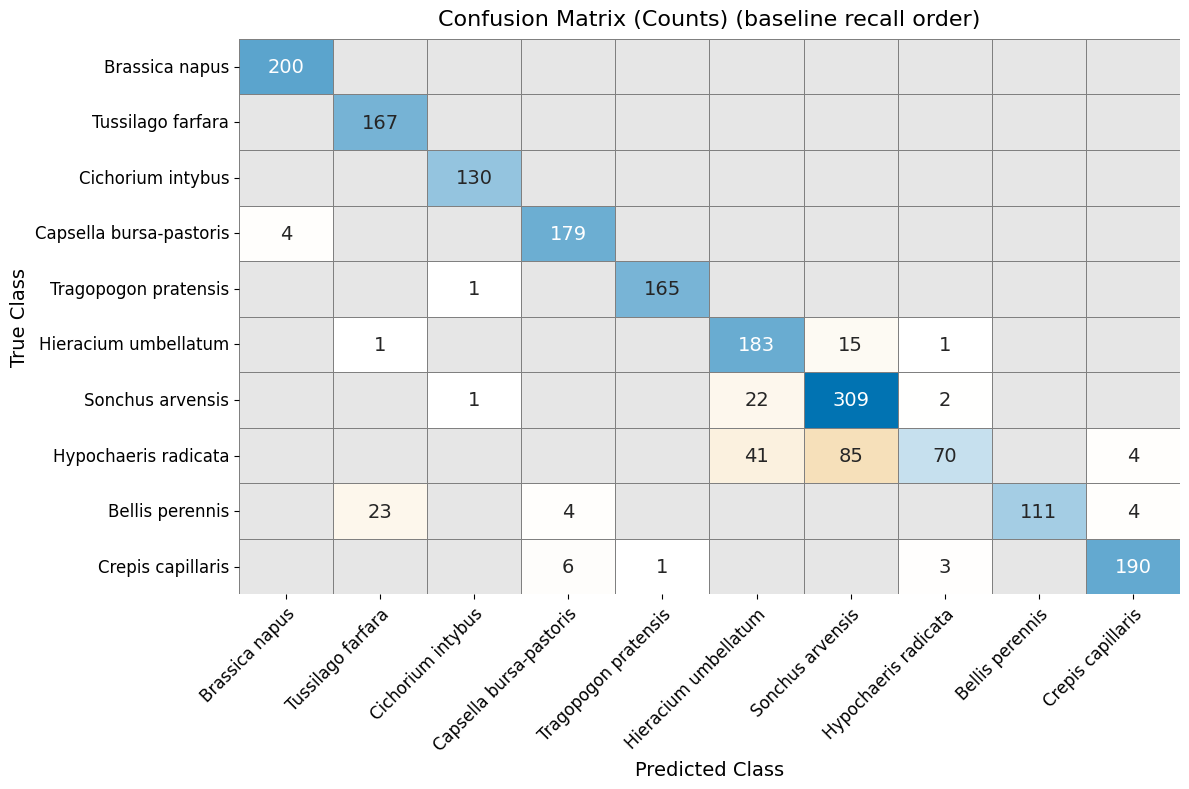

Running case: Crepis test flower = 1009502, Hypo test flower = 1005278
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009502_hypo_1005278' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:15<00:00,  2.89it/s]


Epoch 1/40 | Train Loss: 0.3684, Train Acc: 0.8759
| Val Acc: 0.9782
Val Recall per class: tensor([1.0000, 1.0000, 0.9622, 1.0000, 0.8788, 0.9937, 1.0000, 0.9641, 0.9791,
        1.0000])
Saved new best model (Val Acc = 0.9782)


100%|██████████| 218/218 [01:20<00:00,  2.69it/s]


Epoch 2/40 | Train Loss: 0.0859, Train Acc: 0.9736
| Val Acc: 0.9787
Saved new best model (Val Acc = 0.9787)


...

Epoch 12/40 | Train Loss: 0.0264, Train Acc: 0.9930
| Val Acc: 0.9885


100%|██████████| 218/218 [01:16<00:00,  2.85it/s]


Epoch 13/40 | Train Loss: 0.0538, Train Acc: 0.9855
| Val Acc: 0.9736


100%|██████████| 218/218 [01:18<00:00,  2.78it/s]


Epoch 14/40 | Train Loss: 0.0311, Train Acc: 0.9908
| Val Acc: 0.9908
Early stopping at epoch 14. Best Val Acc = 0.9954 at epoch 6.
Reloaded best model from epoch 6 (Val Acc=0.9954)

=== Backbone Feature Inspection ===
Min of mins: -10.305863380432129
Max of maxs: 18.70815658569336
Mean of batch means: 0.028739104425290325
Mean of batch stds: 1.1671936160228291

Test Accuracy: 0.9292
Test Recall per class:
Class 0 (Bellis perennis): 0.9225
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 1.0000
Class 5 (Hieracium umbellatum): 0.9250
Class 6 (Hypochaeris radicata): 0.7800
Class 7 (Sonchus arvensis): 0.8024
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


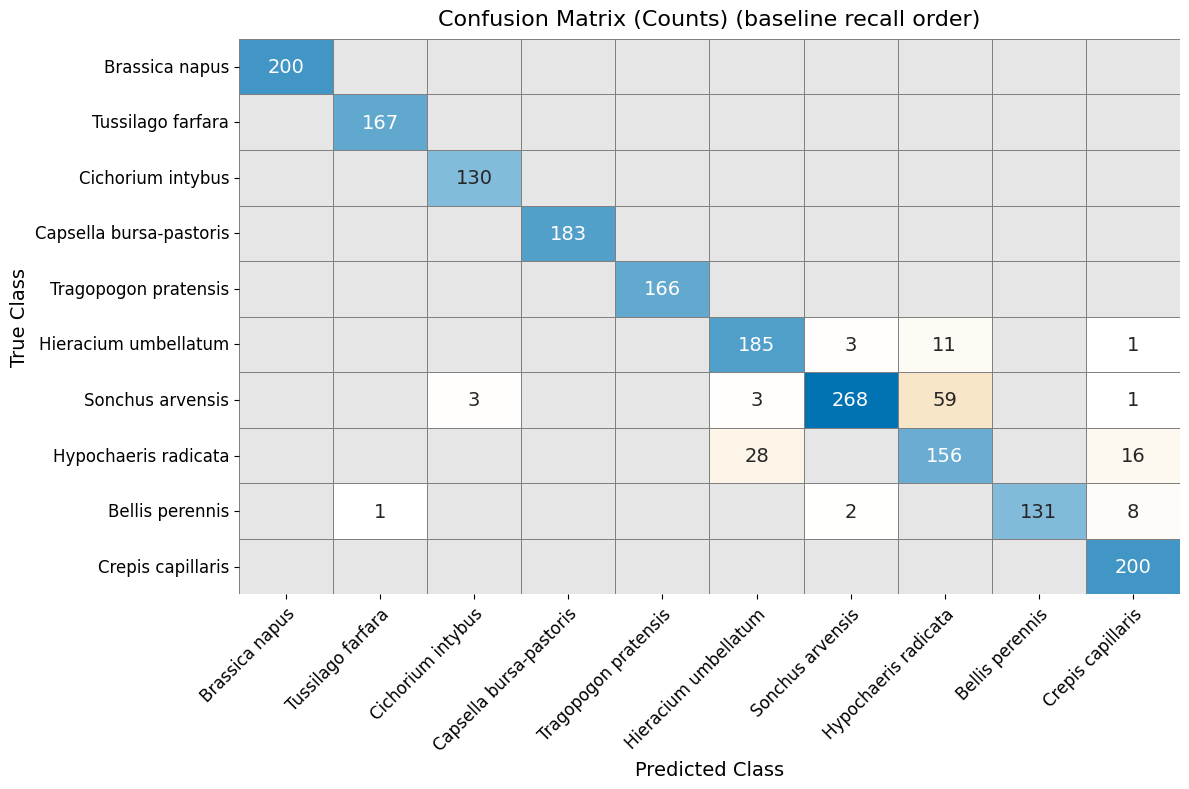

Running case: Crepis test flower = 1009512, Hypo test flower = 1005327
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009512_hypo_1005327' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:17<00:00,  2.81it/s]


Epoch 1/40 | Train Loss: 0.3535, Train Acc: 0.8852
| Val Acc: 0.9132
Val Recall per class: tensor([0.8462, 1.0000, 0.9405, 0.6373, 0.8788, 0.8987, 1.0000, 0.9880, 0.9686,
        1.0000])
Saved new best model (Val Acc = 0.9132)


100%|██████████| 218/218 [01:20<00:00,  2.70it/s]


Epoch 2/40 | Train Loss: 0.0970, Train Acc: 0.9707
| Val Acc: 0.9868
Saved new best model (Val Acc = 0.9868)


...

Epoch 14/40 | Train Loss: 0.0226, Train Acc: 0.9932
| Val Acc: 0.9839


100%|██████████| 218/218 [01:19<00:00,  2.74it/s]


Epoch 15/40 | Train Loss: 0.0138, Train Acc: 0.9957
| Val Acc: 0.9920
Val Recall per class: tensor([1.0000, 0.9945, 0.9892, 0.9845, 1.0000, 0.9937, 1.0000, 0.9701, 0.9895,
        1.0000])


100%|██████████| 218/218 [01:20<00:00,  2.71it/s]


Epoch 16/40 | Train Loss: 0.0242, Train Acc: 0.9915
| Val Acc: 0.9885
Early stopping at epoch 16. Best Val Acc = 0.9960 at epoch 8.
Reloaded best model from epoch 8 (Val Acc=0.9960)

=== Backbone Feature Inspection ===
Min of mins: -15.472477912902832
Max of maxs: 15.583159446716309
Mean of batch means: 0.024283957717268437
Mean of batch stds: 1.101609290623274

Test Accuracy: 0.8559
Test Recall per class:
Class 0 (Bellis perennis): 0.7535
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 1.0000
Class 5 (Hieracium umbellatum): 0.9300
Class 6 (Hypochaeris radicata): 0.0100
Class 7 (Sonchus arvensis): 0.9581
Class 8 (Tragopogon pratensis): 0.9036
Class 9 (Tussilago farfara): 1.0000


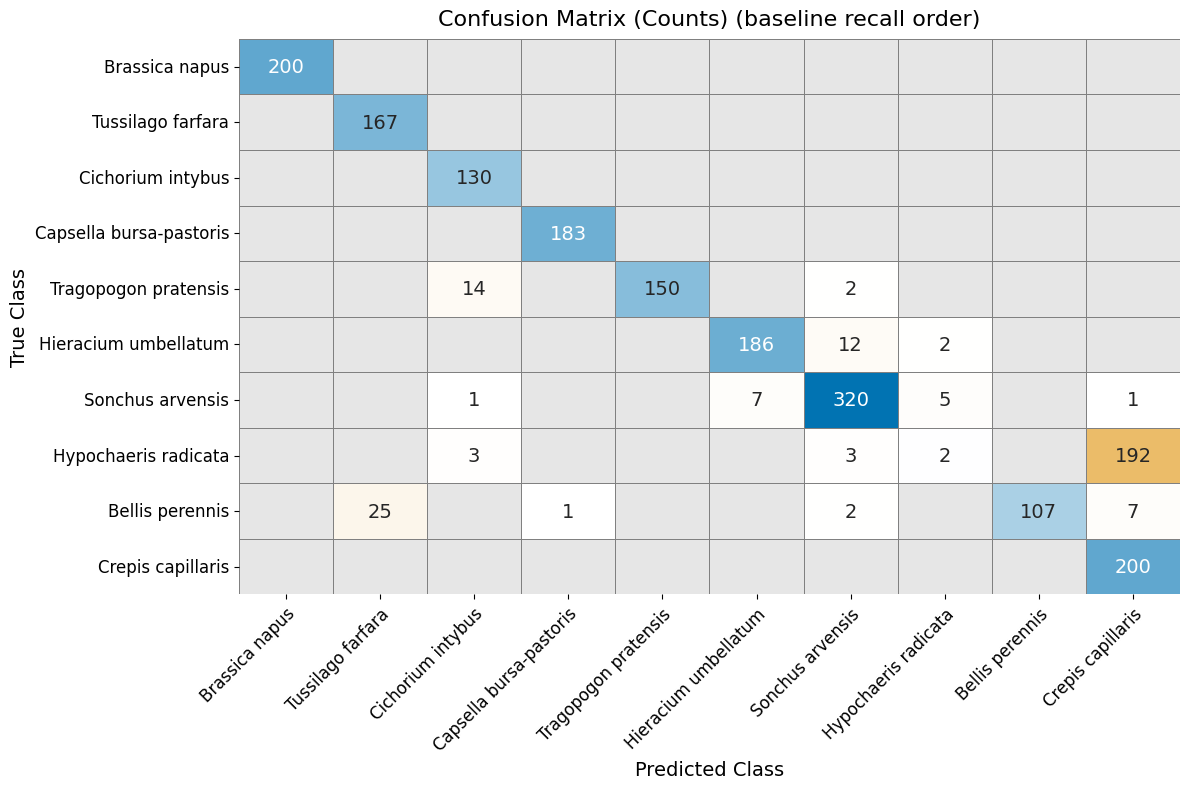

Running case: Crepis test flower = 1009512, Hypo test flower = 1010554
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009512_hypo_1010554' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:15<00:00,  2.89it/s]


Epoch 1/40 | Train Loss: 0.3672, Train Acc: 0.8743
| Val Acc: 0.9695
Val Recall per class: tensor([1.0000, 1.0000, 0.9405, 0.8705, 0.9939, 0.9810, 0.9500, 0.9701, 1.0000,
        1.0000])
Saved new best model (Val Acc = 0.9695)


100%|██████████| 218/218 [01:19<00:00,  2.73it/s]


Epoch 2/40 | Train Loss: 0.1035, Train Acc: 0.9680
| Val Acc: 0.9707
Saved new best model (Val Acc = 0.9707)


...

Epoch 11/40 | Train Loss: 0.0235, Train Acc: 0.9927
| Val Acc: 0.9920


100%|██████████| 218/218 [01:15<00:00,  2.90it/s]


Epoch 12/40 | Train Loss: 0.0062, Train Acc: 0.9977
| Val Acc: 0.9684


100%|██████████| 218/218 [01:16<00:00,  2.86it/s]


Epoch 13/40 | Train Loss: 0.0304, Train Acc: 0.9902
| Val Acc: 0.9862
Early stopping at epoch 13. Best Val Acc = 0.9966 at epoch 5.
Reloaded best model from epoch 5 (Val Acc=0.9966)

=== Backbone Feature Inspection ===
Min of mins: -10.891782760620117
Max of maxs: 15.994406700134277
Mean of batch means: 0.018605039835403927
Mean of batch stds: 1.1137306563189773

Test Accuracy: 0.8694
Test Recall per class:
Class 0 (Bellis perennis): 0.8521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 1.0000
Class 5 (Hieracium umbellatum): 0.9400
Class 6 (Hypochaeris radicata): 0.1300
Class 7 (Sonchus arvensis): 0.8743
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


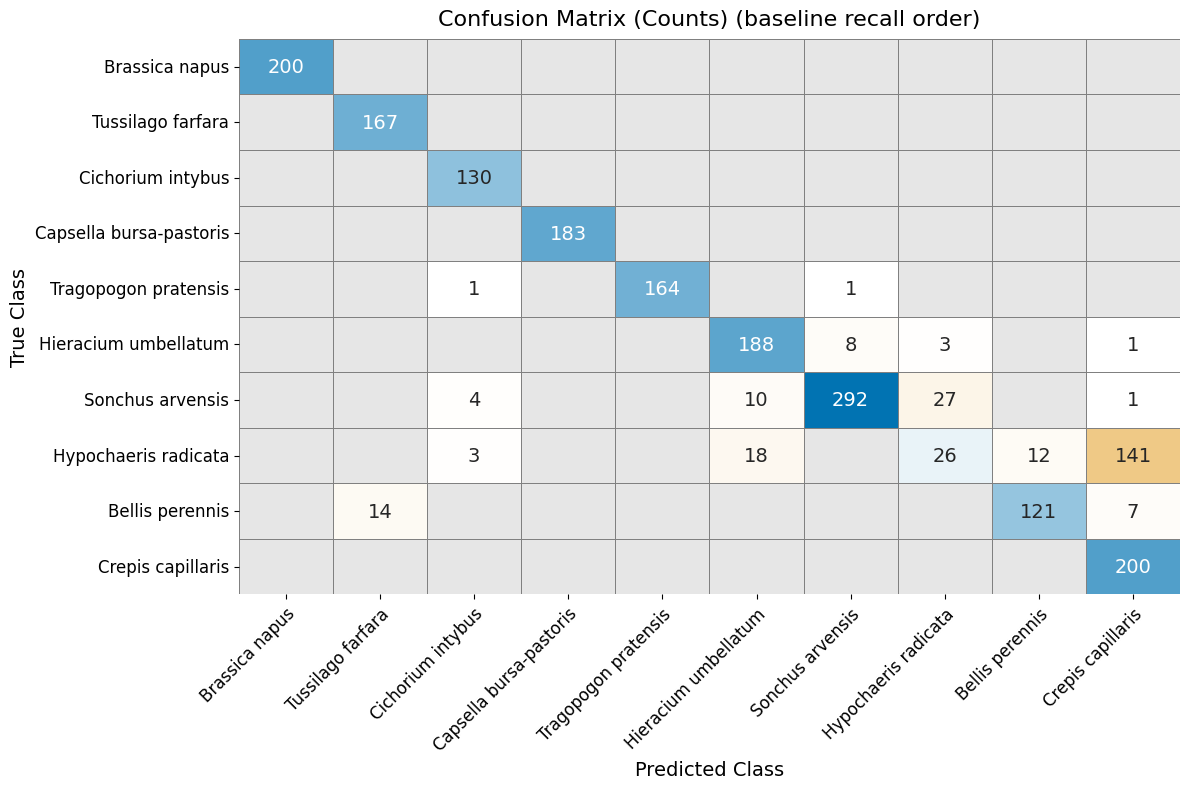

Running case: Crepis test flower = 1009512, Hypo test flower = 1012069
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009512_hypo_1012069' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:16<00:00,  2.86it/s]


Epoch 1/40 | Train Loss: 0.3989, Train Acc: 0.8621
| Val Acc: 0.9667
Val Recall per class: tensor([0.8462, 1.0000, 0.9514, 0.9948, 0.9708, 1.0000, 0.9545, 0.9497, 0.9944,
        1.0000])
Saved new best model (Val Acc = 0.9667)


100%|██████████| 218/218 [01:15<00:00,  2.90it/s]


Epoch 2/40 | Train Loss: 0.0866, Train Acc: 0.9726
| Val Acc: 0.9839
Saved new best model (Val Acc = 0.9839)


...

Epoch 37/40 | Train Loss: 0.0125, Train Acc: 0.9966
| Val Acc: 0.9856


100%|██████████| 218/218 [01:16<00:00,  2.85it/s]


Epoch 38/40 | Train Loss: 0.0088, Train Acc: 0.9973
| Val Acc: 0.9966


100%|██████████| 218/218 [01:17<00:00,  2.80it/s]


Epoch 39/40 | Train Loss: 0.0243, Train Acc: 0.9917
| Val Acc: 0.9943
Early stopping at epoch 39. Best Val Acc = 0.9971 at epoch 31.
Reloaded best model from epoch 31 (Val Acc=0.9971)

=== Backbone Feature Inspection ===
Min of mins: -11.419438362121582
Max of maxs: 15.504815101623535
Mean of batch means: 0.012216116748530738
Mean of batch stds: 1.028331443911693

Test Accuracy: 0.8907
Test Recall per class:
Class 0 (Bellis perennis): 0.6901
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9891
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 1.0000
Class 5 (Hieracium umbellatum): 0.9550
Class 6 (Hypochaeris radicata): 0.3200
Class 7 (Sonchus arvensis): 0.9521
Class 8 (Tragopogon pratensis): 0.9819
Class 9 (Tussilago farfara): 1.0000


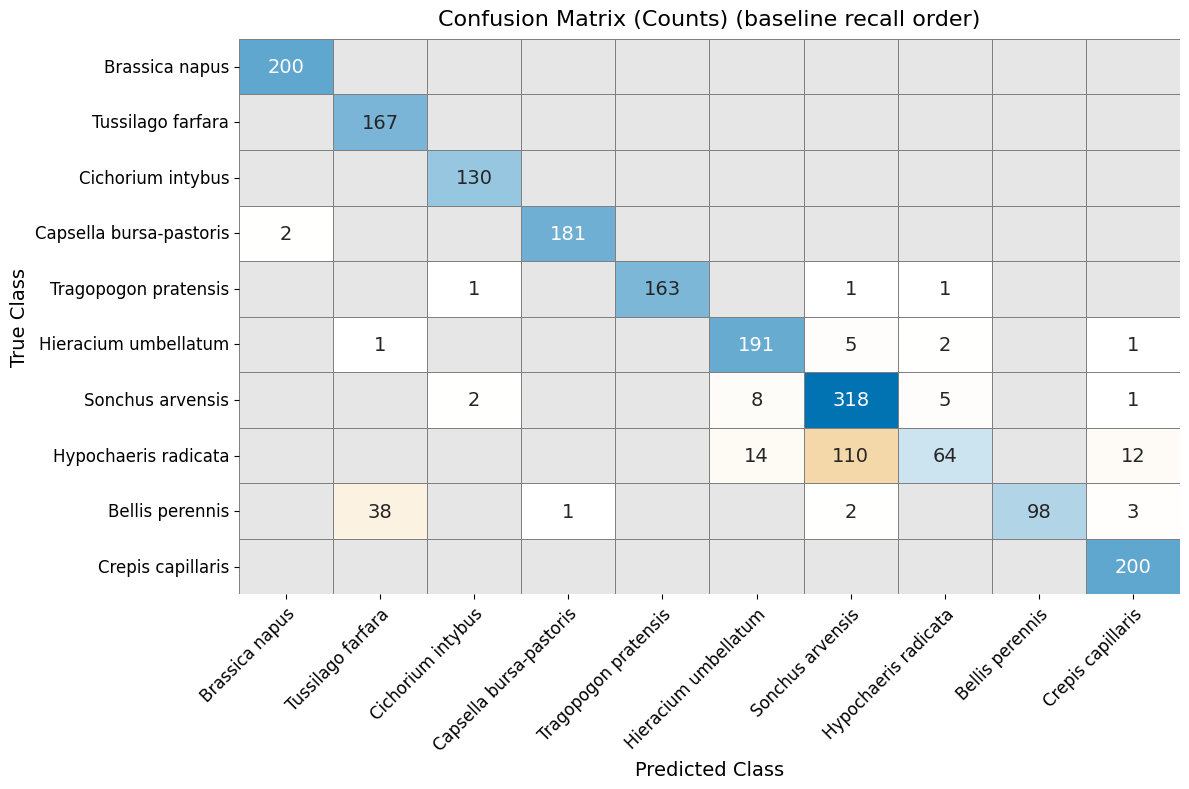

Running case: Crepis test flower = 1009512, Hypo test flower = 1005278
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1009512_hypo_1005278' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:17<00:00,  2.82it/s]


Epoch 1/40 | Train Loss: 0.3870, Train Acc: 0.8684
| Val Acc: 0.9741
Val Recall per class: tensor([1.0000, 1.0000, 0.9405, 0.9326, 0.9576, 1.0000, 0.9750, 0.9641, 0.9791,
        1.0000])
Saved new best model (Val Acc = 0.9741)


100%|██████████| 218/218 [01:22<00:00,  2.65it/s]


Epoch 2/40 | Train Loss: 0.0954, Train Acc: 0.9716
| Val Acc: 0.9868
Saved new best model (Val Acc = 0.9868)


...

Epoch 11/40 | Train Loss: 0.0187, Train Acc: 0.9938
| Val Acc: 0.9902


100%|██████████| 218/218 [01:15<00:00,  2.89it/s]


Epoch 12/40 | Train Loss: 0.0436, Train Acc: 0.9846
| Val Acc: 0.9782


100%|██████████| 218/218 [01:14<00:00,  2.92it/s]


Epoch 13/40 | Train Loss: 0.0145, Train Acc: 0.9948
| Val Acc: 0.9943
Early stopping at epoch 13. Best Val Acc = 0.9954 at epoch 5.
Reloaded best model from epoch 5 (Val Acc=0.9954)

=== Backbone Feature Inspection ===
Min of mins: -9.923715591430664
Max of maxs: 13.694075584411621
Mean of batch means: 0.02092780766543001
Mean of batch stds: 1.0324726544442724

Test Accuracy: 0.9417
Test Recall per class:
Class 0 (Bellis perennis): 0.7817
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.9900
Class 5 (Hieracium umbellatum): 0.9400
Class 6 (Hypochaeris radicata): 0.8150
Class 7 (Sonchus arvensis): 0.9162
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


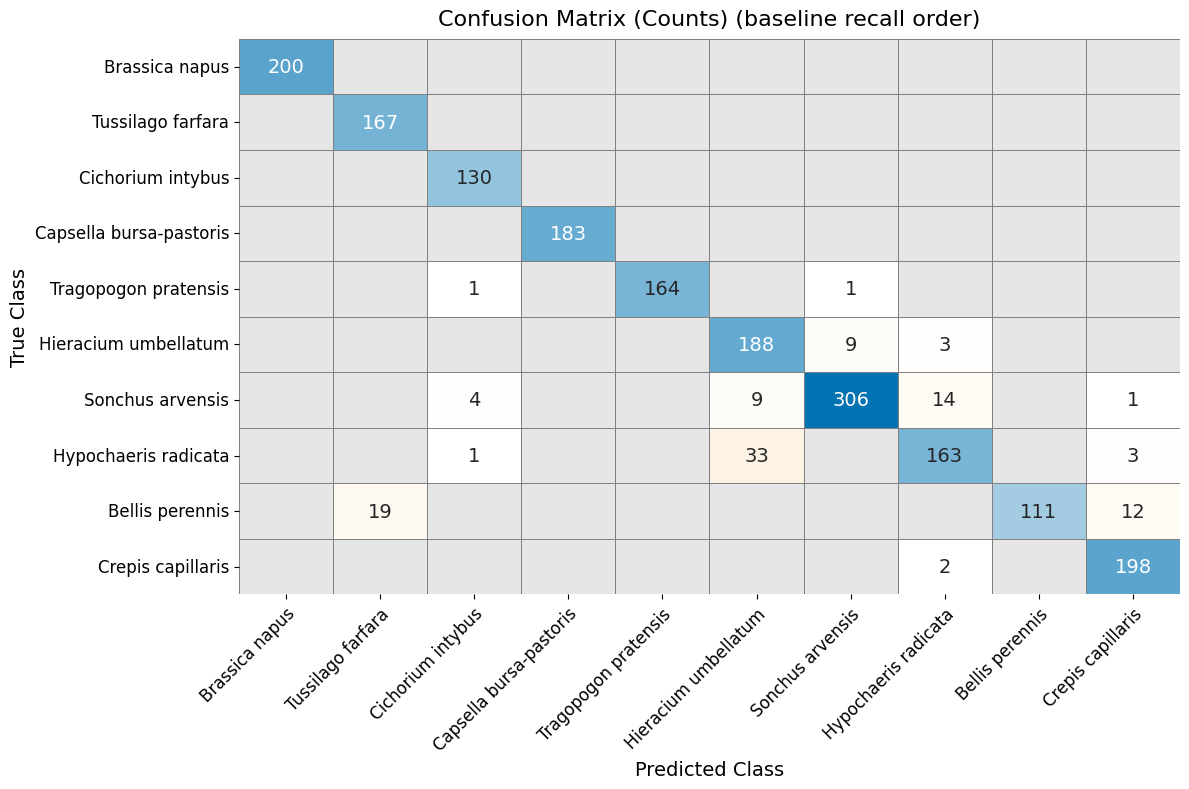

Running case: Crepis test flower = 1010538, Hypo test flower = 1005327
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1010538_hypo_1005327' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:16<00:00,  2.85it/s]


Epoch 1/40 | Train Loss: 0.3507, Train Acc: 0.8848
| Val Acc: 0.9862
Val Recall per class: tensor([1.0000, 0.9945, 0.9784, 0.9896, 1.0000, 0.9804, 0.9939, 0.9441, 0.9832,
        1.0000])
Saved new best model (Val Acc = 0.9862)


100%|██████████| 218/218 [01:24<00:00,  2.58it/s]


Epoch 2/40 | Train Loss: 0.0842, Train Acc: 0.9757
| Val Acc: 0.9782


...

Epoch 22/40 | Train Loss: 0.0240, Train Acc: 0.9937
| Val Acc: 0.9937


100%|██████████| 218/218 [01:19<00:00,  2.73it/s]


Epoch 23/40 | Train Loss: 0.0121, Train Acc: 0.9963
| Val Acc: 0.9948


100%|██████████| 218/218 [01:16<00:00,  2.86it/s]


Epoch 24/40 | Train Loss: 0.0160, Train Acc: 0.9951
| Val Acc: 0.9937
Early stopping at epoch 24. Best Val Acc = 0.9960 at epoch 16.
Reloaded best model from epoch 16 (Val Acc=0.9960)

=== Backbone Feature Inspection ===
Min of mins: -10.16848087310791
Max of maxs: 16.1893310546875
Mean of batch means: 0.008747277488062715
Mean of batch stds: 0.9755319122408257

Test Accuracy: 0.7362
Test Recall per class:
Class 0 (Bellis perennis): 0.5070
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.1100
Class 5 (Hieracium umbellatum): 0.9300
Class 6 (Hypochaeris radicata): 0.0050
Class 7 (Sonchus arvensis): 0.8653
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


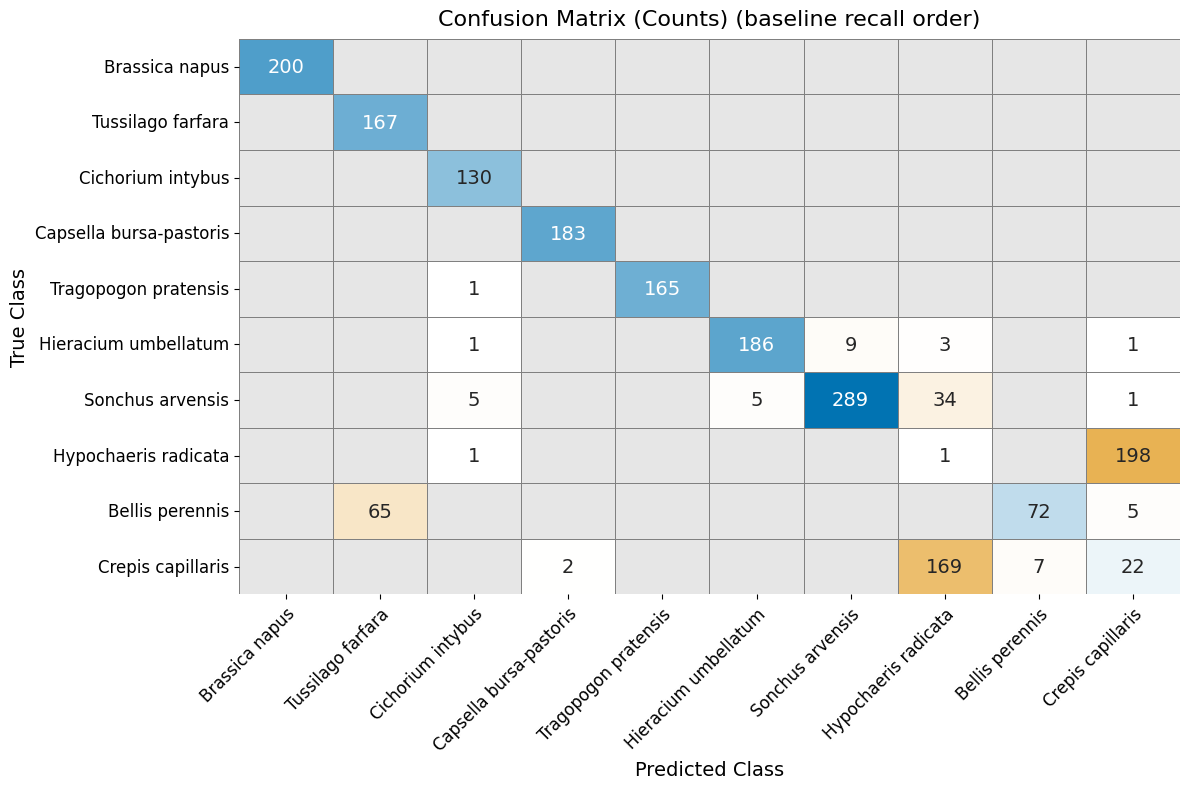

Running case: Crepis test flower = 1010538, Hypo test flower = 1010554
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1010538_hypo_1010554' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:17<00:00,  2.80it/s]


Epoch 1/40 | Train Loss: 0.3611, Train Acc: 0.8773
| Val Acc: 0.9672
Val Recall per class: tensor([1.0000, 1.0000, 0.9405, 0.9326, 1.0000, 0.9804, 0.9573, 0.8771, 0.9944,
        1.0000])
Saved new best model (Val Acc = 0.9672)


100%|██████████| 218/218 [01:18<00:00,  2.78it/s]


Epoch 2/40 | Train Loss: 0.1002, Train Acc: 0.9680
| Val Acc: 0.9862
Saved new best model (Val Acc = 0.9862)


...

Epoch 23/40 | Train Loss: 0.0134, Train Acc: 0.9960
| Val Acc: 0.9908


100%|██████████| 218/218 [01:18<00:00,  2.77it/s]


Epoch 24/40 | Train Loss: 0.0320, Train Acc: 0.9899
| Val Acc: 0.9914


100%|██████████| 218/218 [01:15<00:00,  2.88it/s]


Epoch 25/40 | Train Loss: 0.0051, Train Acc: 0.9980
| Val Acc: 0.9908
Val Recall per class: tensor([1.0000, 1.0000, 0.9784, 0.9948, 1.0000, 1.0000, 0.9451, 0.9944, 0.9944,
        1.0000])
Early stopping at epoch 25. Best Val Acc = 0.9960 at epoch 17.
Reloaded best model from epoch 17 (Val Acc=0.9960)

=== Backbone Feature Inspection ===
Min of mins: -14.28007984161377
Max of maxs: 12.500990867614746
Mean of batch means: 0.019443687422250656
Mean of batch stds: 1.033877287731796

Test Accuracy: 0.7487
Test Recall per class:
Class 0 (Bellis perennis): 0.5211
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9563
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.2000
Class 5 (Hieracium umbellatum): 0.9250
Class 6 (Hypochaeris radicata): 0.5500
Class 7 (Sonchus arvensis): 0.5778
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


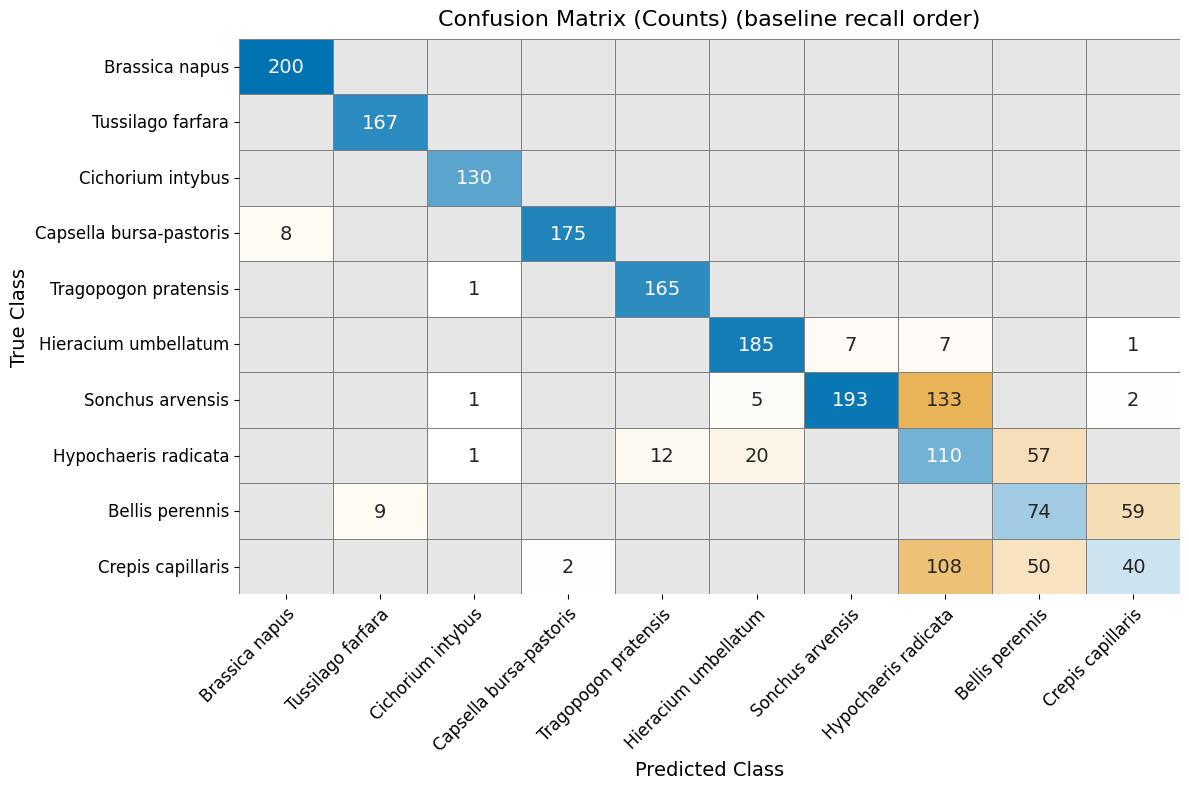

Running case: Crepis test flower = 1010538, Hypo test flower = 1012069
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1010538_hypo_1012069' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:13<00:00,  2.96it/s]


Epoch 1/40 | Train Loss: 0.3696, Train Acc: 0.8784
| Val Acc: 0.8937
Val Recall per class: tensor([1.0000, 0.9945, 0.9622, 0.1451, 0.9940, 0.9608, 0.9880, 1.0000, 0.9820,
        1.0000])
Saved new best model (Val Acc = 0.8937)


100%|██████████| 218/218 [01:19<00:00,  2.73it/s]


Epoch 2/40 | Train Loss: 0.0863, Train Acc: 0.9736
| Val Acc: 0.9707
Saved new best model (Val Acc = 0.9707)


...

Epoch 15/40 | Train Loss: 0.0120, Train Acc: 0.9966
| Val Acc: 0.9638
Val Recall per class: tensor([1.0000, 0.9503, 0.9892, 0.9896, 1.0000, 0.9673, 0.9940, 0.7725, 0.9940,
        1.0000])


100%|██████████| 218/218 [01:13<00:00,  2.96it/s]


Epoch 16/40 | Train Loss: 0.0220, Train Acc: 0.9932
| Val Acc: 0.9856


100%|██████████| 218/218 [01:14<00:00,  2.94it/s]


Epoch 17/40 | Train Loss: 0.0224, Train Acc: 0.9932
| Val Acc: 0.9782
Early stopping at epoch 17. Best Val Acc = 0.9966 at epoch 9.
Reloaded best model from epoch 9 (Val Acc=0.9966)

=== Backbone Feature Inspection ===
Min of mins: -13.187943458557129
Max of maxs: 18.59029769897461
Mean of batch means: 0.03004014936846406
Mean of batch stds: 1.2209809129355385

Test Accuracy: 0.8892
Test Recall per class:
Class 0 (Bellis perennis): 0.9366
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.4300
Class 5 (Hieracium umbellatum): 0.9350
Class 6 (Hypochaeris radicata): 0.7650
Class 7 (Sonchus arvensis): 0.9162
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 0.9940


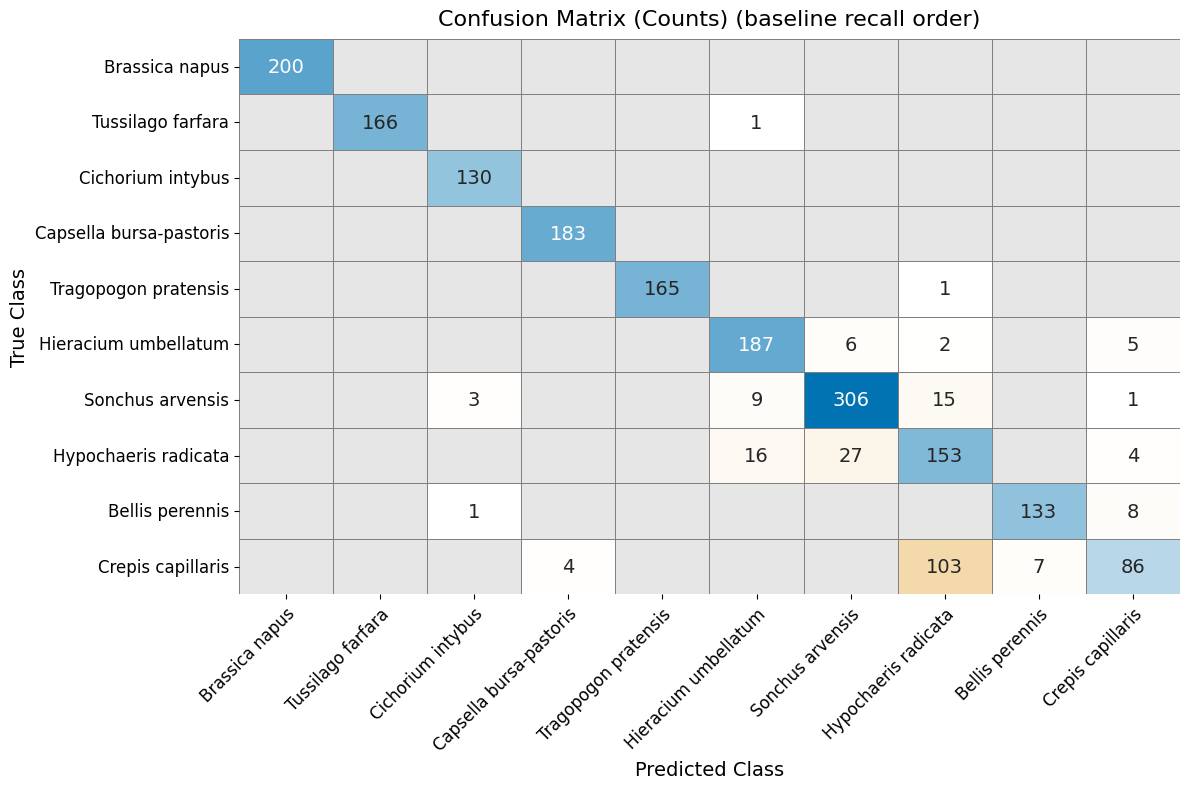

Running case: Crepis test flower = 1010538, Hypo test flower = 1005278
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1010538_hypo_1005278' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:15<00:00,  2.91it/s]


Epoch 1/40 | Train Loss: 0.3997, Train Acc: 0.8654
| Val Acc: 0.9787
Val Recall per class: tensor([1.0000, 1.0000, 0.9459, 0.9845, 0.9759, 0.9739, 0.9817, 0.9385, 0.9944,
        0.9942])
Saved new best model (Val Acc = 0.9787)


100%|██████████| 218/218 [01:16<00:00,  2.84it/s]


Epoch 2/40 | Train Loss: 0.0905, Train Acc: 0.9723
| Val Acc: 0.9856
Saved new best model (Val Acc = 0.9856)


...

Epoch 11/40 | Train Loss: 0.0421, Train Acc: 0.9879
| Val Acc: 0.9609


100%|██████████| 218/218 [01:16<00:00,  2.84it/s]


Epoch 12/40 | Train Loss: 0.0311, Train Acc: 0.9897
| Val Acc: 0.9862


100%|██████████| 218/218 [01:19<00:00,  2.75it/s]


Epoch 13/40 | Train Loss: 0.0460, Train Acc: 0.9864
| Val Acc: 0.9563
Early stopping at epoch 13. Best Val Acc = 0.9931 at epoch 5.
Reloaded best model from epoch 5 (Val Acc=0.9931)

=== Backbone Feature Inspection ===
Min of mins: -17.01268196105957
Max of maxs: 20.038862228393555
Mean of batch means: 0.01855523102596158
Mean of batch stds: 1.0758995511492744

Test Accuracy: 0.7388
Test Recall per class:
Class 0 (Bellis perennis): 0.5000
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.1450
Class 5 (Hieracium umbellatum): 0.7800
Class 6 (Hypochaeris radicata): 0.9600
Class 7 (Sonchus arvensis): 0.4012
Class 8 (Tragopogon pratensis): 0.9518
Class 9 (Tussilago farfara): 1.0000


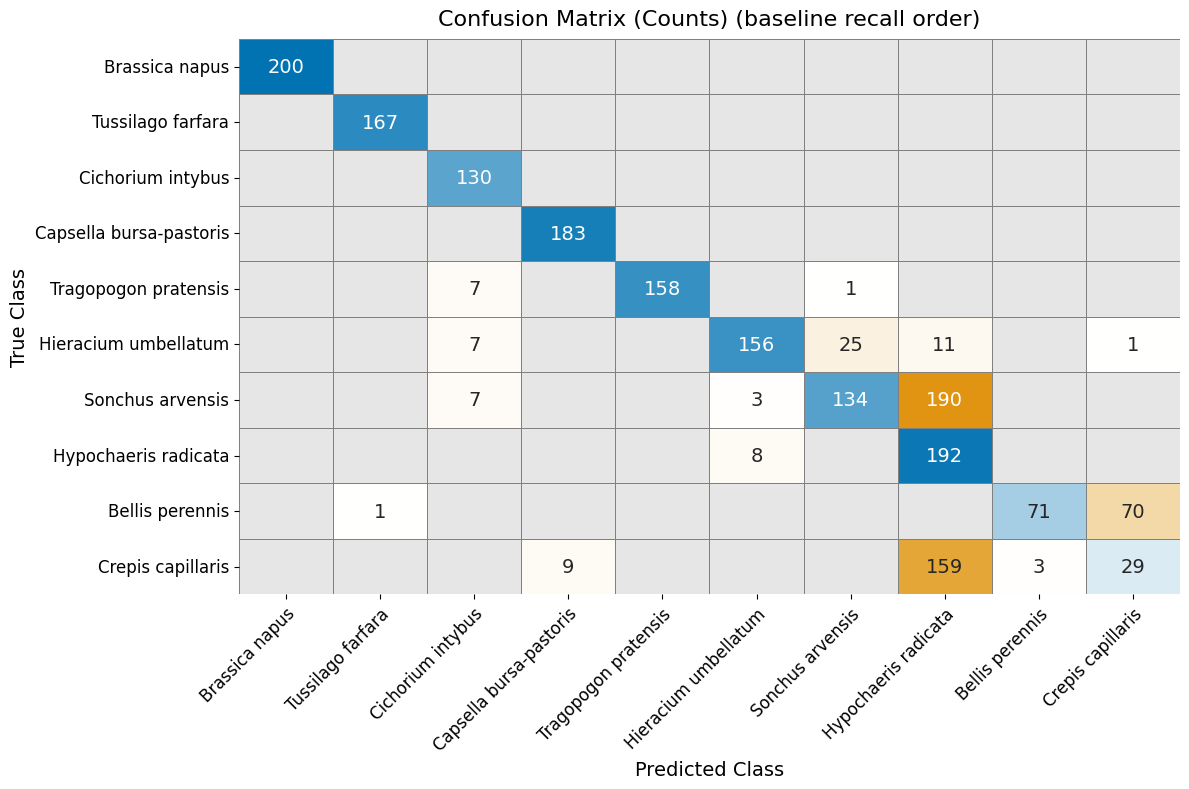

Running case: Crepis test flower = 1005299, Hypo test flower = 1005327
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1005299_hypo_1005327' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:18<00:00,  2.78it/s]


Epoch 1/40 | Train Loss: 0.3493, Train Acc: 0.8836
| Val Acc: 0.9667
Val Recall per class: tensor([1.0000, 1.0000, 0.9568, 0.8756, 0.9273, 1.0000, 0.9875, 0.9701, 0.9634,
        1.0000])
Saved new best model (Val Acc = 0.9667)


100%|██████████| 218/218 [01:17<00:00,  2.83it/s]


Epoch 2/40 | Train Loss: 0.1069, Train Acc: 0.9701
| Val Acc: 0.9925
Saved new best model (Val Acc = 0.9925)


...

Epoch 27/40 | Train Loss: 0.0080, Train Acc: 0.9977
| Val Acc: 0.9885


100%|██████████| 218/218 [01:22<00:00,  2.66it/s]


Epoch 28/40 | Train Loss: 0.0007, Train Acc: 0.9999
| Val Acc: 0.9943


100%|██████████| 218/218 [01:24<00:00,  2.59it/s]


Epoch 29/40 | Train Loss: 0.0006, Train Acc: 0.9997
| Val Acc: 0.9960
Early stopping at epoch 29. Best Val Acc = 0.9977 at epoch 21.
Reloaded best model from epoch 21 (Val Acc=0.9977)

=== Backbone Feature Inspection ===
Min of mins: -9.670517921447754
Max of maxs: 11.032438278198242
Mean of batch means: 0.018238452894395584
Mean of batch stds: 1.0370580856917335

Test Accuracy: 0.8496
Test Recall per class:
Class 0 (Bellis perennis): 0.9718
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.8350
Class 5 (Hieracium umbellatum): 0.9450
Class 6 (Hypochaeris radicata): 0.1100
Class 7 (Sonchus arvensis): 0.8144
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 0.9940


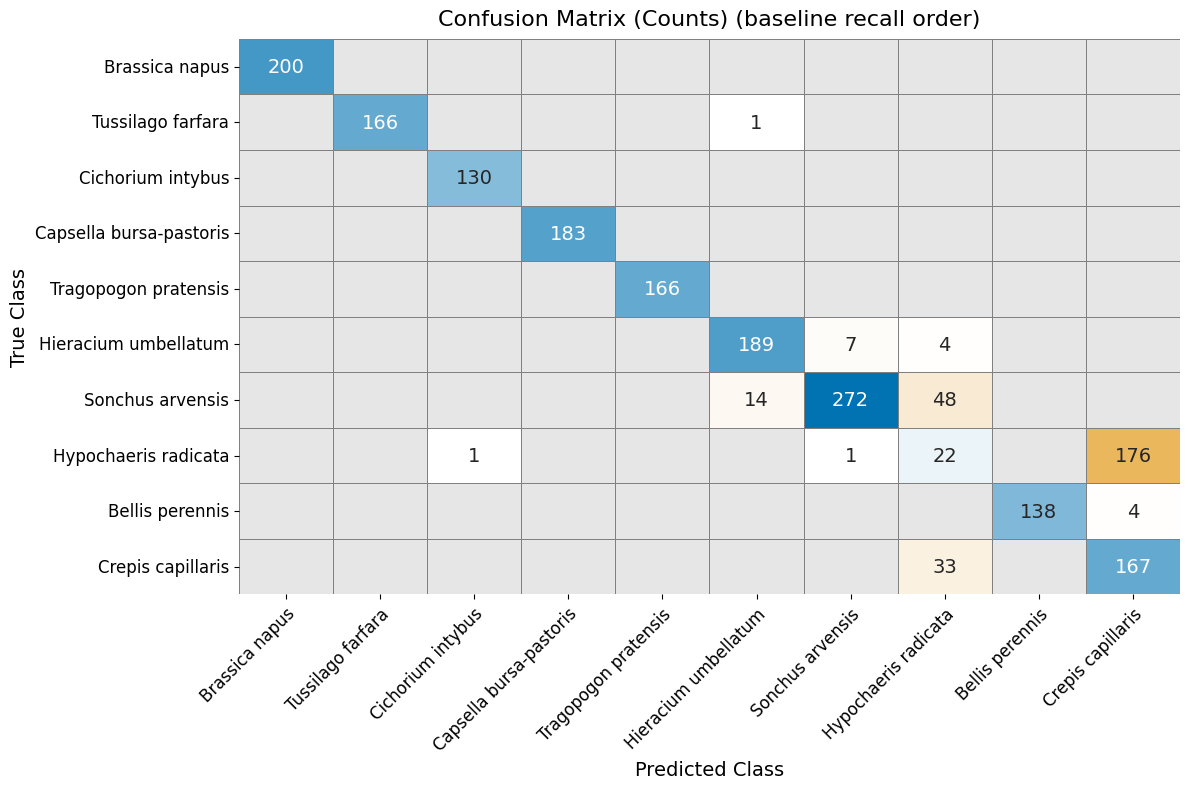

Running case: Crepis test flower = 1005299, Hypo test flower = 1010554
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1005299_hypo_1010554' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:18<00:00,  2.77it/s]


Epoch 1/40 | Train Loss: 0.3745, Train Acc: 0.8763
| Val Acc: 0.9851
Val Recall per class: tensor([1.0000, 1.0000, 0.9459, 0.9689, 1.0000, 1.0000, 0.9812, 0.9760, 0.9895,
        0.9942])
Saved new best model (Val Acc = 0.9851)


100%|██████████| 218/218 [01:22<00:00,  2.63it/s]


Epoch 2/40 | Train Loss: 0.0919, Train Acc: 0.9728
| Val Acc: 0.9931
Saved new best model (Val Acc = 0.9931)


...

Epoch 8/40 | Train Loss: 0.0152, Train Acc: 0.9955
| Val Acc: 0.9897


100%|██████████| 218/218 [01:22<00:00,  2.63it/s]


Epoch 9/40 | Train Loss: 0.0077, Train Acc: 0.9981
| Val Acc: 0.9914


100%|██████████| 218/218 [01:21<00:00,  2.69it/s]


Epoch 10/40 | Train Loss: 0.0508, Train Acc: 0.9813
| Val Acc: 0.9195
Val Recall per class: tensor([1.0000, 0.9337, 0.9892, 0.9741, 1.0000, 0.9937, 1.0000, 0.9222, 0.4398,
        1.0000])
Early stopping at epoch 10. Best Val Acc = 0.9931 at epoch 2.
Reloaded best model from epoch 2 (Val Acc=0.9931)

=== Backbone Feature Inspection ===
Min of mins: -14.131494522094727
Max of maxs: 15.993571281433105
Mean of batch means: 0.024016465839059628
Mean of batch stds: 1.1802557159642704

Test Accuracy: 0.7992
Test Recall per class:
Class 0 (Bellis perennis): 0.9648
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9344
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.4050
Class 5 (Hieracium umbellatum): 0.9750
Class 6 (Hypochaeris radicata): 0.2100
Class 7 (Sonchus arvensis): 0.7455
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


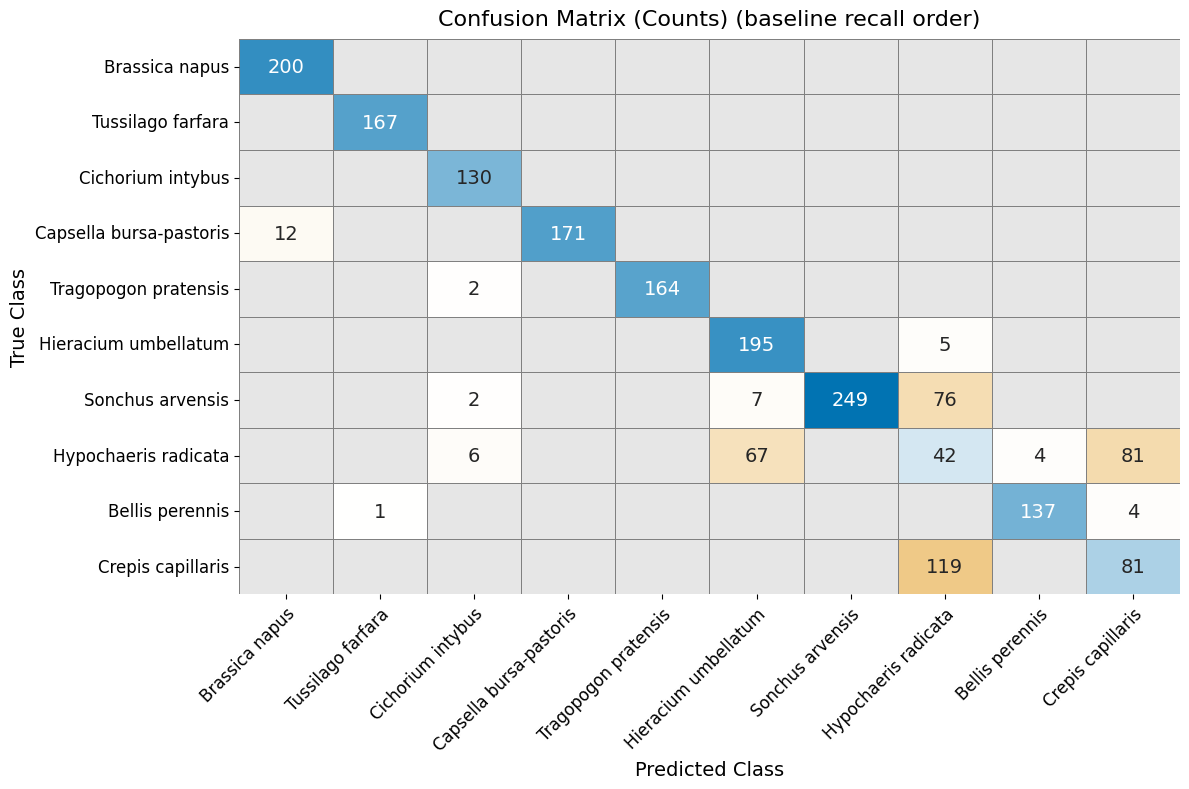

Running case: Crepis test flower = 1005299, Hypo test flower = 1012069
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1005299_hypo_1012069' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:18<00:00,  2.78it/s]


Epoch 1/40 | Train Loss: 0.3655, Train Acc: 0.8764
| Val Acc: 0.9776
Val Recall per class: tensor([1.0000, 1.0000, 0.9568, 0.9430, 0.9357, 0.9873, 1.0000, 0.9665, 0.9944,
        1.0000])
Saved new best model (Val Acc = 0.9776)


100%|██████████| 218/218 [01:22<00:00,  2.64it/s]


Epoch 2/40 | Train Loss: 0.0811, Train Acc: 0.9764
| Val Acc: 0.9391


...

Epoch 10/40 | Train Loss: 0.0080, Train Acc: 0.9970
| Val Acc: 0.9908
Val Recall per class: tensor([0.9527, 1.0000, 0.9784, 1.0000, 0.9883, 0.9937, 1.0000, 1.0000, 0.9944,
        1.0000])


100%|██████████| 218/218 [01:13<00:00,  2.96it/s]


Epoch 11/40 | Train Loss: 0.0331, Train Acc: 0.9897
| Val Acc: 0.9937


100%|██████████| 218/218 [01:15<00:00,  2.88it/s]


Epoch 12/40 | Train Loss: 0.0108, Train Acc: 0.9967
| Val Acc: 0.9793
Early stopping at epoch 12. Best Val Acc = 0.9948 at epoch 4.
Reloaded best model from epoch 4 (Val Acc=0.9948)

=== Backbone Feature Inspection ===
Min of mins: -10.886857986450195
Max of maxs: 14.201074600219727
Mean of batch means: 0.024518399482180715
Mean of batch stds: 1.0604405872157363

Test Accuracy: 0.8231
Test Recall per class:
Class 0 (Bellis perennis): 0.4437
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.8470
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.2650
Class 5 (Hieracium umbellatum): 0.9200
Class 6 (Hypochaeris radicata): 0.7400
Class 7 (Sonchus arvensis): 0.9491
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


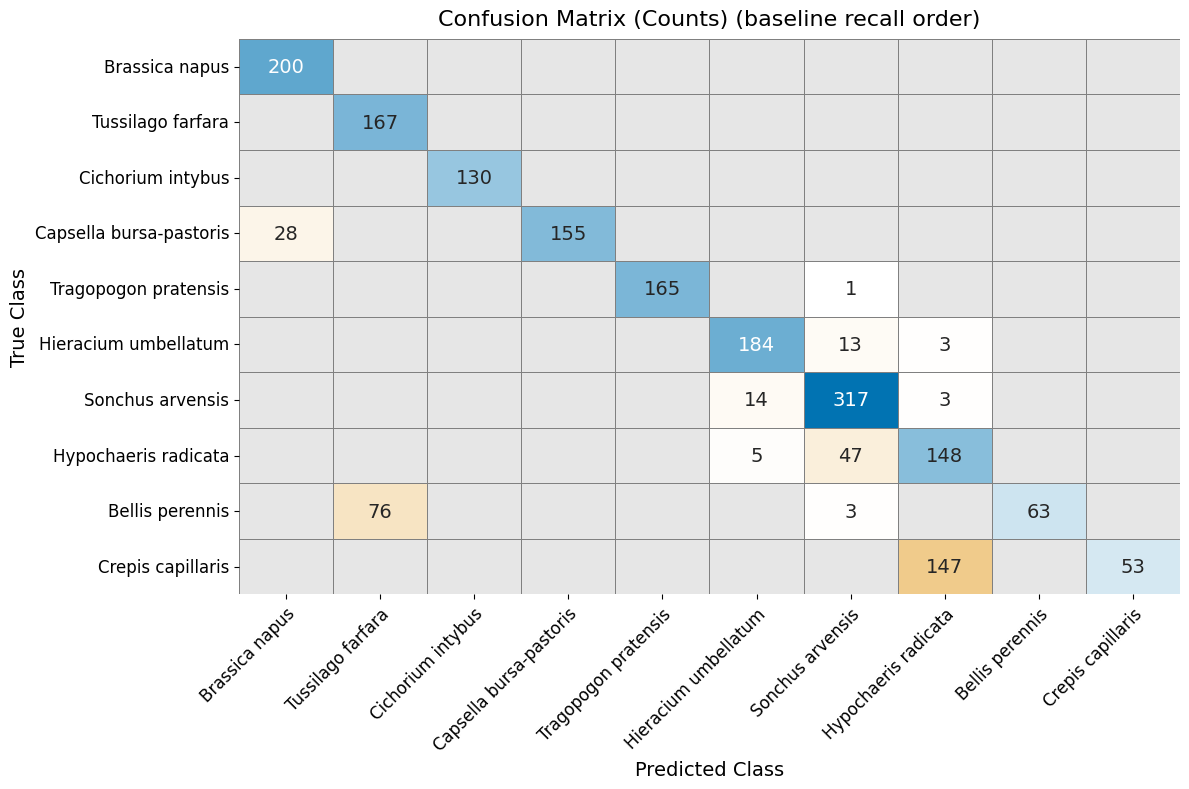

Running case: Crepis test flower = 1005299, Hypo test flower = 1005278
Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from 'train_case_crepis_1005299_hypo_1005278' with 8078 samples.

=========== None ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from 'None' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (add 53)
  Cichorium intybus: 870 (add 0)
  Crepis capillaris: 800 (add 70)
  Hieracium umbella

100%|██████████| 218/218 [01:19<00:00,  2.74it/s]


Epoch 1/40 | Train Loss: 0.3670, Train Acc: 0.8769
| Val Acc: 0.9707
Val Recall per class: tensor([0.9763, 1.0000, 0.9514, 0.9896, 0.9939, 0.9937, 0.9438, 0.8623, 0.9895,
        1.0000])
Saved new best model (Val Acc = 0.9707)


100%|██████████| 218/218 [01:21<00:00,  2.67it/s]


Epoch 2/40 | Train Loss: 0.0792, Train Acc: 0.9761
| Val Acc: 0.9908
Saved new best model (Val Acc = 0.9908)


...

Epoch 8/40 | Train Loss: 0.0416, Train Acc: 0.9866
| Val Acc: 0.9862


100%|██████████| 218/218 [01:19<00:00,  2.74it/s]


Epoch 9/40 | Train Loss: 0.0264, Train Acc: 0.9924
| Val Acc: 0.9891


100%|██████████| 218/218 [01:16<00:00,  2.86it/s]


Epoch 10/40 | Train Loss: 0.0154, Train Acc: 0.9964
| Val Acc: 0.9655
Val Recall per class: tensor([1.0000, 0.8453, 1.0000, 0.9896, 1.0000, 0.9430, 0.8938, 0.9760, 1.0000,
        1.0000])
Early stopping at epoch 10. Best Val Acc = 0.9908 at epoch 2.
Reloaded best model from epoch 2 (Val Acc=0.9908)

=== Backbone Feature Inspection ===
Min of mins: -10.106881141662598
Max of maxs: 20.134923934936523
Mean of batch means: 0.030593813952587194
Mean of batch stds: 1.1690767436731058

Test Accuracy: 0.8096
Test Recall per class:
Class 0 (Bellis perennis): 0.9789
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.2150
Class 5 (Hieracium umbellatum): 0.9850
Class 6 (Hypochaeris radicata): 0.6800
Class 7 (Sonchus arvensis): 0.5868
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


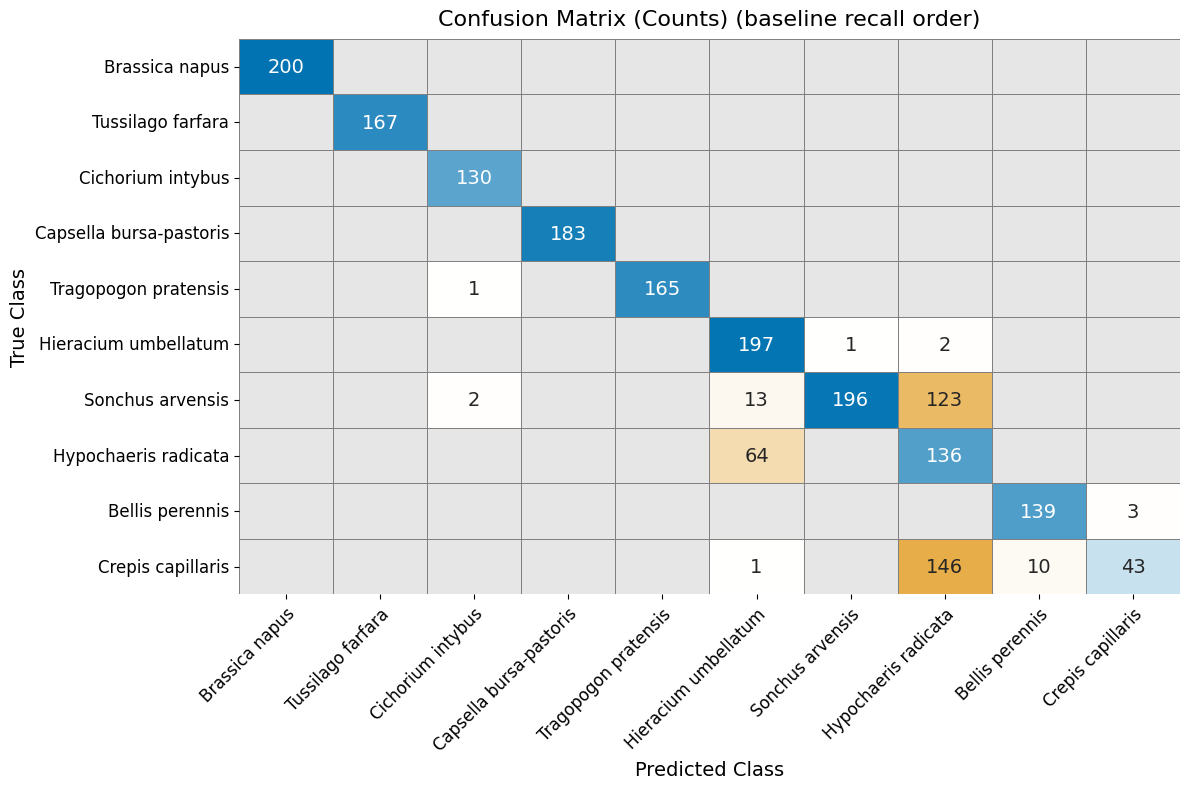

In [30]:
results = []
num_classes = len(classes)
for crepis_flower in CREPIS_FLOWERS:
    for hypo_flower in HYPO_FLOWERS:
        print("=" * 80)
        print(f"Running case: Crepis test flower = {crepis_flower}, Hypo test flower = {hypo_flower}")
        seed_everything(SEED, deterministic=True)
        train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class, classes = setup_sensitivity_datasets(
            crepis_test_flower=crepis_flower,
            hypo_test_flower=hypo_flower,
            train_dir=TRAIN_DIR,
            test_dir=TEST_DIR,
            excel_path=EXCEL_PATH,
            fill_missing_bool=True,
            val_bool=True,
            aug_bool=True,
            norm_bool=False,
            sep_val_bool=False,
            quota_bool=False,
            bootstrap_impute_bool=False,
            seed=42,
            return_flowerid=False
        )

        
        model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=3e-4,
            weight_decay=0.05
        )

        history = train_model(
                model=model
                ,train_dataset=train_dataset
                ,val_dataset=val_dataset
                ,optimizer=optimizer
                ,loss_fn=loss_fn
                ,device=device
                ,model_name=f"convnext_fill_val_aug_sensi_C{crepis_flower}_H{hypo_flower}.pth"
                ,num_classes=num_classes
                ,batch_size=32
                ,epochs=40
                ,early_stopping_patience=8
                
            )
        
        test_loader = DataLoader(
                test_dataset,
                batch_size=32,
                shuffle=False,
                num_workers=0
            )

        ckpt = torch.load(f"models/saved_trained_models/convnext_fill_val_aug_sensi_C{crepis_flower}_H{hypo_flower}.pth", map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        model.to(device)

        recall_per_class, accuracy, probs, ys, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
        print(f"Test Accuracy: {accuracy:.4f}")
        print("Test Recall per class:")
        for i, r in enumerate(recall_per_class):
            print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

        plot_confusion_matrix(conf, idx_to_class, normalize=False)
        macro_recall = recall_per_class.mean()

        metrics = {
            "crepis_test_flower": crepis_flower,
            "hypo_test_flower": hypo_flower,
            "test_accuracy": accuracy,
            "recall_per_class":recall_per_class
            ,"macro_recall": macro_recall
        }

        results.append(metrics)

In [31]:
results

[{'crepis_test_flower': '1009502',
  'hypo_test_flower': '1005327',
  'test_accuracy': 0.8803330063819885,
  'recall_per_class': tensor([0.9155, 0.9900, 1.0000, 1.0000, 1.0000, 0.9850, 0.0000, 0.9641, 0.9940,
          1.0000]),
  'macro_recall': tensor(0.8849)},
 {'crepis_test_flower': '1009502',
  'hypo_test_flower': '1010554',
  'test_accuracy': 0.8584807515144348,
  'recall_per_class': tensor([0.6549, 1.0000, 0.9945, 1.0000, 1.0000, 0.9650, 0.0350, 0.9401, 0.9880,
          1.0000]),
  'macro_recall': tensor(0.8578)},
 {'crepis_test_flower': '1009502',
  'hypo_test_flower': '1012069',
  'test_accuracy': 0.8865764737129211,
  'recall_per_class': tensor([0.7817, 1.0000, 0.9781, 1.0000, 0.9500, 0.9150, 0.3500, 0.9251, 0.9940,
          1.0000]),
  'macro_recall': tensor(0.8894)},
 {'crepis_test_flower': '1009502',
  'hypo_test_flower': '1005278',
  'test_accuracy': 0.929240345954895,
  'recall_per_class': tensor([0.9225, 1.0000, 1.0000, 1.0000, 1.0000, 0.9250, 0.7800, 0.8024, 1.0000,


In [32]:
acc = [r["test_accuracy"] for r in results]
macro = [float(r["macro_recall"]) for r in results]
recalls = np.array([r["recall_per_class"].cpu().numpy() for r in results])

print("Test accuracy mean:", np.mean(acc))
print("Test accuracy std (sample):", np.std(acc, ddof=1))

print("Macro recall mean:", np.mean(macro))
print("Macro recall std (sample):", np.std(macro, ddof=1))

print("Recall per class mean:")
print(recalls.mean(axis=0))

print("Recall per class std (sample):")
print(recalls.std(axis=0, ddof=1))

Test accuracy mean: 0.844172727316618
Test accuracy std (sample): 0.06356049616827927
Macro recall mean: 0.8546508885920048
Macro recall std (sample): 0.05790355147054392
Recall per class mean:
[0.7610035  0.999375   0.98121583 1.         0.6590625  0.934375
 0.40375003 0.8242889  0.9841867  0.9992515 ]
Recall per class std (sample):
[0.1880773  0.0025     0.04049957 0.         0.3802202  0.04686417
 0.3447777  0.16671644 0.02418407 0.00204529]
